In [1]:
import numpy as np
import time
import pandas as pd
import datetime
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation
import pickle
from tqdm import tqdm
import glob, os
np.set_printoptions(threshold=np.inf, precision=10)

In [44]:
# Optimizer Parameters
upperbound_fs = 15
lowerbound_fs = 1
delta_t = 1
clr = 0.5 # Cost-Loss Ratio
baro = 0.12 # The true probability that the event occurs

# Discount Parameters
zeta = 0
discount_denom = 1 + zeta

base_date = datetime.datetime(2021, 1, 1, 0, 0)
window_size = delta_t

# upperbound_ft = 200
# lowerbound_ft = 1

In [3]:
# Consumption Parameters
current_phases = np.array([-0.000887, -0.0732, -0.0412]) # Current for idle, sense, transmit respectively. 
charge_capacity = 0.500      # 2.7531  # Ah
length_of_sense_event = 4 # seconds
length_of_transmit_event = 6 # seconds

In [4]:
# Energy Harvest Parameters
harvesting_Schedule = np.array([
    (1, True),
])
### IMPORTANT: MAKE SURE THAT THE SUM OF THIS EQUALS delta_t

In [5]:
lut_discharge = pd.read_csv('./data/voltage_vs_SoC_LUT.csv')
soc_values = lut_discharge.iloc[:, 0].values / 100
ocv_values = lut_discharge.iloc[:, 1].values
ocv_interpolator = interp1d(soc_values, ocv_values, kind='linear', fill_value='extrapolate')

In [6]:
def estimate_energy_capacity(soc):
    '''
    Returns the estimated energy left, in J, given the SoC calculated using the CC Method.
    '''
    soc_for_integration = np.linspace(0.015, soc, 1000)  # 1.5% is the minimum permitted SoC.
    ocv_for_integration = ocv_interpolator(soc_for_integration)
    integral_result = np.trapezoid(ocv_for_integration, soc_for_integration)
    estimated_energy_left = charge_capacity * integral_result * 3600

    return estimated_energy_left

In [7]:
nominal_energy_capacity = estimate_energy_capacity(1)

In [8]:
def cc_method(previous_soc, phase_duration, phase_current):
    soc_present = previous_soc + (1/charge_capacity) * (phase_duration * phase_current * 100)
    return max(0, min(100, soc_present))

In [9]:
def calculate_harvested_energy(power, duration, efficiency=0.10):
    '''Expected Amount of Energy Harvested in window k, returns in Joules'''
    harvested_energy = power * duration * efficiency
    return harvested_energy * 3600

In [10]:
def energy_ratio(soc, f_s_k, f_t_k, window, peak_power):
    '''
    Calculates the State of Energy at the end of the k-th window given a set of frequency (f_s_k, f_t_k) and energy harvest.
    soc: The state of charge
    f_s_k, f_t_k: The set of decision variables
    window: The time index in which we are operating, aka k
    peak_power: The peak power harvested
    '''
    durations = harvesting_Schedule[:, 0]
    harvest_flags = harvesting_Schedule[:, 1]
    harvested_energy = 0
    current_soc = soc

    sense_duration = (length_of_sense_event/3600 * (f_s_k * durations))
    transmit_duration = (length_of_transmit_event/3600 * (f_t_k * durations))
    idle_duration = durations - sense_duration - transmit_duration
    for i in range(len(durations)):
        current_soc = cc_method(current_soc, sense_duration[i], current_phases[1])
        current_soc = cc_method(current_soc, transmit_duration[i], current_phases[2])
        current_soc = cc_method(current_soc, idle_duration[i], current_phases[0])
        if harvest_flags[i]:
            for hour_offset in range(durations[i]):
                harvested_energy += calculate_harvested_energy(peak_power[window], 1)
                
        energy_at_end_of_slice = estimate_energy_capacity(current_soc / 100)
        energy_ratio = (energy_at_end_of_slice + harvested_energy)/(nominal_energy_capacity) * 100
        energy_ratio = max(0, min(100, energy_ratio)) # This is the SoE
        
        harvested_charge = harvested_energy / 3.6   # This is C, 3.6 is the Nominal Voltage
        current_soc = ((0.01 * current_soc * charge_capacity) + (harvested_charge / 3600)) / (charge_capacity)*100  ### This is from 0 - 100
        current_soc = max(0, min(100, current_soc))
        harvested_energy = 0
    return energy_ratio, current_soc

In [11]:
def hit_rate_function(frequency):
    ''' Hit Rate as a function of freuqency'''
    return 92.165 - 4.7277*np.exp(-0.1209*frequency)

In [12]:
def far_function(frequency):
    ''' False Alarm Rate as a function of freuqency'''
    return 0.2329*np.exp(-0.3036*frequency) + 0

In [13]:
def value_of_eps(clr, baro, frequency):
    numerator = min(clr, baro) - baro + (hit_rate_function(frequency) / 100) * baro * (1 - clr) - (far_function(frequency) / 100) * (1 - baro) * clr
    denominator = min(clr, baro) - baro * clr
    return numerator / denominator

In [14]:
def normalize_veps(value, clr, baro):
    ''' 
    Normalize VoI for fair decision making
    '''
    max_value = value_of_eps(clr, baro, upperbound_fs)
    min_value = value_of_eps(clr, baro, lowerbound_fs)
    return (value - max_value)/(max_value - min_value)

In [15]:
# solar_df = pd.read_csv("C:/LUMS/Full Deployment/GHI Data from 1Jan2019 to 1Jan2025 at LUMS.csv", header=9, engine='python')
solar_df = pd.read_csv(r"./data/GHI Data USGS Site.csv", header=9, engine='python', skipfooter=0)
solar_df['datetime'] = pd.to_datetime(solar_df[['YEAR', 'MO', 'DY', 'HR']].astype(str).agg('-'.join, axis=1), format='%Y-%m-%d-%H')
solar_df['MO'] = solar_df['datetime'].dt.month
solar_df['DY'] = solar_df['datetime'].dt.day
solar_df['HR'] = solar_df['datetime'].dt.hour
historical_avg = (solar_df.groupby(['MO', 'DY', 'HR'])['ALLSKY_SFC_SW_DWN'].transform('mean'))
solar_df['Average'] = historical_avg

In [41]:
def compute_belief(start_date, end_date):
    """
    Computes harvest belief by finding the max ALLSKY_SFC_SW_DWN in a given date range.
    current_window: Current MPC window.
    start_date, end_date: Date range to consider.
    """
    mask = (solar_df['datetime'] >= start_date) & (solar_df['datetime'] <= end_date)
    filtered_df = solar_df[mask]
    if not filtered_df.empty:
        return filtered_df['ALLSKY_SFC_SW_DWN'].iloc[0]
    else:
        return 0

In [42]:
def update_harvest_belief(current_window, total_windows):
    '''
    Updates the beliefs about the future harvest using ground truth values.
    Assumes a solar panel size of 0.01 m^2
    '''
    panel_size=0.01
    energy_availability = 1
    beliefs = []
    start_dates = [base_date + pd.Timedelta(hours=(current_window + i) * window_size) for i in range(total_windows)]
    end_dates = [start + pd.Timedelta(hours=window_size) for start in start_dates]
    max_ghi_values = [compute_belief(S, E) for S, E in zip(start_dates, end_dates)]
    beliefs = [max_ghi*panel_size*energy_availability for max_ghi in max_ghi_values]

    # Comment this when not simulating worst-case scenario
    # beliefs = [0]*total_windows
    
    return beliefs

In [17]:
# threat_data_raw = pd.read_csv(r"C:\LUMS\USB Backup\LUMS\Namal Dataset\threat_data_raw.csv")
threat_data_raw = pd.read_csv(r"./data/processed_mississippi_data_interpolated_2021_2022.csv")
threat_data_raw = threat_data_raw.interpolate(method='polynomial', order=5)
threat_data_raw["Unit"] = pd.to_datetime(threat_data_raw["Unit"])
# threat_data_raw['Unit'] = threat_data_raw['Unit'].dt.tz_localize("Asia/Karachi")

C:\Users\wit\AppData\Local\Temp\ipykernel_16168\3726792508.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  threat_data_raw = threat_data_raw.interpolate(method='polynomial', order=5)


In [18]:
def update_threat_belief(current_window):
    '''
    Uses the maximum observed value in the past window to update the threat
    current_window: Current time index
    '''
    start_date = base_date + pd.Timedelta(hours=current_window * delta_t)
    end_date = start_date + pd.Timedelta(hours=delta_t)
    start_date = pd.to_datetime(start_date).tz_localize("Asia/Karachi")
    end_date = pd.to_datetime(end_date).tz_localize("Asia/Karachi")
    mask = (threat_data_raw['Unit'] >= start_date) & (threat_data_raw['Unit'] <= end_date)
    filtered = threat_data_raw[mask]
    if not filtered.empty:
        moving_average = filtered['Instantaneous Stream Level (ft)'].max()
        return moving_average

In [19]:
def update_threat_belief_perfect(current_window, horizon):
    '''
    Uses the observed values from the data to give a perfect prediction of water levels
    current_window: Current time index
    horizon: Future Time Horizon we are looking into
    '''
    water_levels = np.zeros(shape=horizon)
    start_date = base_date + pd.Timedelta(hours=current_window * delta_t)
    end_date = start_date + pd.Timedelta(hours=horizon * delta_t)
    start_date = pd.to_datetime(start_date).tz_localize("Asia/Karachi")
    end_date = pd.to_datetime(end_date).tz_localize("Asia/Karachi")
    mask = (threat_data_raw['Unit'] >= start_date) & (threat_data_raw['Unit'] <= end_date)
    filtered = threat_data_raw[mask]
    for i in range(horizon):
        new_mask = (filtered["Unit"] >= start_date) & (filtered["Unit"] <= start_date+pd.Timedelta(hours=1))
        water_levels[i] = filtered[new_mask]["Instantaneous Stream Level (ft)"].max()
        start_date += pd.Timedelta(hours=1)
    return water_levels

Constraint Functions

In [20]:
def energy_constraint(params, effective_horizon, initial_soc, harvest_belief, epsilon=1):
    SoC = initial_soc
    f_s = params[:effective_horizon]
    # f_t = params[effective_horizon:]
    constraints = []
    for k in range(effective_horizon):
        E_value, SoC = energy_ratio(SoC, f_s[k], f_s[k], k, harvest_belief) # The value returned is in %
        constraints.append(E_value - epsilon)  # Ensure SoE >= epsilon
    return np.array(constraints)

In [21]:
def constr_f_t(params, effective_horizon):
    f_s = params[:effective_horizon]
    f_t = params[effective_horizon:]
    constraints = []
    for k in range(effective_horizon):
        pos = f_s[k]-f_t[k]
        constraints.append(pos)
    return constraints

In [22]:
def kernel(x1, x2, t=1.0, sigma=1):
    sqdist = np.subtract.outer(x1, x2)**2
    return sigma**2 * np.exp(-0.5*sqdist / (t**2))

In [23]:
def growth(t, alpha=0.05):
    return 1 + alpha * t

In [24]:
def growth_martingale(t, alpha=0.1):
    """
    MMFE property: Variance grows linearly with lead time.
    Standard Deviation (scaling factor) grows with sqrt(t).
    """
    return alpha * np.sqrt(t + 1e-6)

-------------------------------------------------------------------------------------

HELPER FUNCTIONS IMPLEMENTING THE KALMAN FILTER USING MPC SELECTED FREQUENCIES

-------------------------------------------------------------------------------------

In [25]:
def get_observational_data(threat_data_raw, inter_transmission_time):
    df = threat_data_raw.copy()
    df['Unit'] = pd.to_datetime(df['Unit'])
    df = df.set_index('Unit')
    resampled_parts = []
    start = df.index.min()
    for dt_min in tqdm(inter_transmission_time):
        end = start + pd.Timedelta(hours=1)
        df_hour = df.loc[start:end]
        if df_hour.empty:
            print(f"Empty: {df_hour}")
            print(f"End Time: {end}")
        if not df_hour.empty:
            dt_sec = int(round(dt_min * 60))
            df_r = (
                df_hour
                .resample(f'{dt_sec}s', origin=start, closed='left', label='left')
                .mean()
                .interpolate(method='time')
            )
            resampled_parts.append(df_r)
            # mask = (df_r.index >= start) & (df_r.index < end)
            # resampled_parts.append(df_r[mask])
        start = end
    threat_resampled = pd.concat(resampled_parts, ignore_index=False)
    threat_resampled.index = threat_resampled.index.tz_localize(None)
    return threat_resampled

In [26]:
def generate_confidence_fans(observed_df, sigma, bias, n_samples=1000, horizon_hours=4, step_hours=1, t=1, alpha=0.2):
    """
    Generate ensemble trajectories over a fixed forecasting horizon
    using observation timestamps, suitable for EnKF updates.
    Forecast uncertainty increases linearly with time
    """
    fontsize=19
    linewidth=3
    # plt.figure(figsize=(14, 5))
    # plt.style.use('seaborn-v0_8')
    _, ax1 = plt.subplots(figsize=(12.5,5))
    # observed_df = observed_df.tz_localize(None)
    observed_df = observed_df.tz_localize(None)

    records = []
    times = observed_df.index
    signal = observed_df["Instantaneous Stream Level (ft)"].to_numpy()

    start_time = times[0]
    end_time = times[-1]
    step = pd.Timedelta(hours=step_hours)
    horizon = pd.Timedelta(hours=horizon_hours)

    window_id = 0
    t0 = start_time
    ax1.plot(times, signal, color='black', linewidth=linewidth, label='Observations', zorder=10)
    first_ensemble=True
    pbar = tqdm(total=int((end_time - start_time) / step) + 1)
    while t0 <= end_time:
        t_end = t0 + horizon
        mask = (times >= t0) & (times <= t_end)
        ts_window = times[mask]

        if len(ts_window) < 2:
            t0 += step
            continue

        current_signal = signal[mask]

        # relative times in hours
        rel_t = (ts_window - ts_window[0]).total_seconds() / 3600
        n_steps = len(rel_t)
        # rng = np.random.default_rng(window_id)
        rng = np.random.default_rng(None)
        base_cov = kernel(rel_t, rel_t, t=t, sigma=sigma)
        g = growth_martingale(rel_t, alpha=alpha)
        cov_matrix = base_cov * np.outer(g, g)
                
        bias_mean = bias[0]
        bias_std = bias[1]
        member_biases = rng.normal(loc=bias_mean, scale=bias_std, size=n_samples)
        noise = rng.multivariate_normal(np.zeros(n_steps), cov_matrix, size=n_samples)
        ensembles = current_signal + noise + member_biases[:, np.newaxis]

        window_start_time = ts_window[0]
        if window_start_time.hour % horizon_hours == 0:
            lower = np.percentile(ensembles, 2.5, axis=0)
            upper = np.percentile(ensembles, 97.5, axis=0)
            ax1.fill_between(ts_window, lower, upper, alpha=0.3)
            lbl = "Ensemble Realization" if first_ensemble else None
            ax1.plot(ts_window, ensembles[-1], color='teal', alpha=0.5, label=lbl)
            first_ensemble = False

        window_values = ensembles.ravel()
        window_times = np.tile(ts_window, n_samples)
        ensemble_ids = np.repeat(np.arange(n_samples), n_steps)
        step_ids = np.tile(np.arange(n_steps), n_samples)
        window_df = pd.DataFrame({
            "window_id": window_id,
            "ensemble_id": ensemble_ids,
            "step": step_ids,
            "timestamp": window_times,
            "value": window_values
        })
        records.append(window_df)

        # for e in range(n_samples):
        #     for k, ts in enumerate(ts_window):
        #         records.append({
        #             "window_id": window_id,
        #             "ensemble_id": e,
        #             "step": k,
        #             "timestamp": ts,
        #             "value": ensembles[e, k]
        #         })
        window_id += 1
        t0 += step
        pbar.update(1)
    pbar.close()
    # df_long = pd.DataFrame(records)
    df_long = pd.concat(records, ignore_index=True)
    ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
    for ax in [ax1]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color('black')
    ax1.set_ylabel("Stream Level (ft)", fontsize=fontsize)
    ax1.set_xlabel("Time", fontsize=fontsize)
    ax1.ticklabel_format(axis='y', style='plain')
    ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    # ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax1.legend(ncols=1, fancybox=True, shadow=True,
           frameon=True, facecolor='lightgrey', prop={'size':15})
    # plt.savefig('./Noise Ensembles Small Error', dpi=150, bbox_inches='tight')
    return df_long

In [27]:
def generate_forecast_from_kf_estimate(X_a, timestamps_full, obs_df_dedup, window_id, sigma, alpha, t, n_ens, seed, bias):
    """
    Extends KF trajectories by:
    1. Preserving the analyzed state X_a for [0, H].
    2. Appending trajectories for [H, 2H] based on ground truth + correlated noise.
    3. Applying a vertical shift to ensure continuity at the H boundary.
    """
    rng = np.random.default_rng(seed)
    bias_mean = bias[0]
    bias_std = bias[1]
    
    H_len = X_a.shape[0]  # Number of steps already in the KF state
    total_len = len(timestamps_full)
    ext_len = total_len - H_len
    # print(f"#Points in X:{H_len}, #PointsAdded:{ext_len}")

    prefix_times = timestamps_full[:H_len]
    suffix_times = timestamps_full[H_len:]

    # print(f"Prefix Times: {prefix_times}")
    # print(f"Suffix Times: {suffix_times}")
    records = []

    # Add the KF analysis (Prefix) to records
    for e in range(n_ens):
        for k, ts in enumerate(prefix_times):
            records.append({
                "window_id": window_id,
                "ensemble_id": e,
                "step": k,
                "timestamp": ts,
                "value": X_a[k, e]
            })
    if ext_len <= 0:
        return pd.DataFrame(records)

    # Generate the Extension (Suffix)
    # Extract ground truth signal for the suffix timestamps
    # Assuming obs_df_dedup is indexed by timestamp
    # print("Extending...")
    true_signal = obs_df_dedup.loc[suffix_times, "Instantaneous Stream Level (ft)"].to_numpy()
    # print(f"True Value at suffix: {true_signal}")
    # Relative time in hours for the covariance kernel
    rel_t = (suffix_times - suffix_times.iloc[0]).dt.total_seconds().to_numpy() / 3600

    base_cov = kernel(rel_t, rel_t, t=t, sigma=sigma)
    g = growth_martingale(rel_t, alpha=alpha)
    cov = base_cov * np.outer(g, g)

    # mean=np.zeros(ext_len)
    noise = rng.multivariate_normal(mean=np.zeros(ext_len), cov=cov, size=n_ens)
    # print(f"Noise: {noise[:5]}")

    # Enforce continuity and append to records
    for e in range(n_ens):
        last_kf_val = X_a[-1, e]
        raw_ext = true_signal + noise[e]
        
        # Calculate the jump between KF end and Signal start
        # shift = (Analysis at H) - (Noisy Signal at H)
        shift = last_kf_val - raw_ext[0]
        ext_traj = raw_ext + shift

        for j, ts in enumerate(suffix_times):
            records.append({
                "window_id": window_id,
                "ensemble_id": e,
                "step": H_len + j,
                "timestamp": ts,
                "value": ext_traj[j]
            })
    df = pd.DataFrame(records)
    return df

In [28]:
def get_freqs_from_pkl(path_to_pkl):
    # path_to_dropbox = r'C:\LUMS\RMPC\smpc-unaware-errorlarge-bf-clipped-fullinit-500mah-fixedconstr-fixedsampling'
    with open(path_to_pkl, "rb") as f:
        loaded_data = pickle.load(f)
    system_states_unaware_bf=loaded_data
    first_elements_sense = [np.atleast_1d(arr)[0] for arr in system_states_unaware_bf['freq_sensing']]
    first_elements_transmit = [np.atleast_1d(arr)[0] for arr in system_states_unaware_bf['freq_transmission']]
    inter_transmission_time = [60/x for x in first_elements_transmit]
    inter_sample_time = [60/x for x in first_elements_sense]
    return inter_sample_time, inter_transmission_time

In [29]:
def fixed_horizon_enkf_segment(obs_df_dedup, obs_df_clean, n_ens, bias, R, Q, horizon_hours, t_windows, init_state_length, forecast_df, alpha, sigma, step_hours, frequency,
                                window_start, window_end, carry_state=None):
    """
    Runs the EnKF for windows [window_start, window_end).
    
    carry_state: dict with keys {X_a, obs_ptr, state_length, state_start_time}
                 Pass None for the very first segment.
    
    Returns: (segment_df, carry_state)
    """
    horizon_hours = horizon_hours + delta_t
    y = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]
    y_times = obs_df_dedup.reset_index()["Unit"]

    freq_str = f"{int(step_hours * 60)}min"
    counts = (obs_df_dedup.reset_index()
              .groupby(pd.Grouper(key='Unit', freq=freq_str))
              .size()
              .reset_index(name='n_samples'))
    obs_per_window = counts["n_samples"]

    all_step_dfs = []

    forecast_lookup = {
        wid: group.pivot(index='step', columns='ensemble_id', values='value').values
        for wid, group in forecast_df.groupby('window_id')
    }
    state_lengths = np.array([forecast_lookup[k].shape[0] for k in range(t_windows - 1)])

    # --- Restore or initialise carry state ---
    if carry_state is None:
        # Very first segment: initialise from forecast_df window 0
        state_length = init_state_length
        raw_values = forecast_df.loc[forecast_df["window_id"] == 0, "value"].values
        X_a = raw_values.reshape(n_ens, -1).T[:state_length, :]
        obs_ptr = 0
        state_start_time = y_times.iloc[0]
    else:
        X_a             = carry_state["X_a"]
        obs_ptr         = carry_state["obs_ptr"]
        state_length    = carry_state["state_length"]
        state_start_time = carry_state["state_start_time"]

    # --- Main loop (identical logic to original) ---
    # rng = np.random.default_rng(seed=1485) 
    rng = np.random.default_rng(None)
    for k in range(window_start, window_end):

        if k != 0:
            handover_index = obs_per_window[k - 1]
            filtered_state_raw = X_a[handover_index:, :]
            timestamps_full = y_times.iloc[obs_ptr : obs_ptr + state_length].reset_index(drop=True)

            # current_forecast_seed = rng.integers(0, 1000000)
            forecast_df = generate_forecast_from_kf_estimate(
                filtered_state_raw, timestamps_full, obs_df_clean,
                window_id=k, sigma=sigma, alpha=alpha, t=1000, n_ens=n_ens, seed=None, bias=bias
            )
            forecast_df = forecast_df.sort_values(by=["ensemble_id", "step"]).reset_index(drop=True)
            X_a = forecast_df.pivot(index="step", columns="ensemble_id", values="value").values

        for i in range(obs_per_window[k]):
            y_obs = y.loc[obs_ptr + i : obs_ptr + state_length + i + 1]

            # Predict
            X_f_prior = X_a.copy() 
            future_start = i
            num_future = state_length - future_start
            epsilon = 1e-6
            full_Q = np.eye(state_length) * epsilon
            if num_future > 0:
                dt = 1.0 / frequency
                future_steps = np.arange(num_future)
                future_times = future_steps * dt
                kernel_v = kernel(future_times, future_times, t=1000, sigma=Q)
                growth_v = growth_martingale(future_times, alpha=alpha)
                Q_future = kernel_v * np.outer(growth_v, growth_v) * dt
                full_Q[future_start:, future_start:] = Q_future
            process_noise = rng.multivariate_normal(np.zeros(state_length), full_Q, size=n_ens).T
            X_f = X_f_prior + process_noise

            # Update
            x_mean_f = np.mean(X_f, axis=1, keepdims=True)
            A = X_f - x_mean_f
            # C = (A @ A.T) / (n_ens - 1)
            # H = np.zeros((1, state_length))
            # H[0, i] = 1
            # S = (H @ C @ H.T) + R
            # K = (C @ H.T) / S

            A_row_i = A[i, :]
            S = (A_row_i @ A_row_i) / (n_ens - 1) + R
            K = (A @ A_row_i) / ((n_ens - 1) * S)
            K = K.reshape(-1, 1)

            obs = y_obs.loc[obs_ptr + i]

            d_perturbed = obs + rng.normal(0, np.sqrt(R), size=n_ens) # Stochastic EnKF
            innovations = d_perturbed - X_f[i, :]
            X_a = X_f + K @ innovations.reshape(1, -1)

            current_times = y_times.iloc[obs_ptr : obs_ptr + state_length]
            # all_step_dfs.append(pd.DataFrame({
            #     'window_id':   np.int16(k),
            #     'obs_step':    np.int16(i),
            #     'ensemble_id': np.int16(np.repeat(np.arange(n_ens), state_length)),
            #     'step':        np.int16(np.tile(np.arange(state_length), n_ens)),
            #     'timestamp':   np.tile(current_times, n_ens),
            #     'value':       np.float32(X_a.ravel(order='F')),

            #     # State Tracking
            #     # 'x_prior_pure':     np.float32(X_f_prior.ravel(order='F')),
            #     # 'process_noise':    np.float32(process_noise.ravel(order='F')),
            #     'x_forecast':       np.float32(X_f.ravel(order='F')),
            #     # 'x_analysis':       np.float32(X_a.ravel(order='F')),

            #     # Observation Data
            #     # 'obs_raw':          np.float32(obs),
            #     # 'd_perturbed':      np.float32(np.repeat(d_perturbed, state_length)), 
            #     # 'innovation':       np.float32(np.repeat(innovations, state_length)),

            #     # Filter Diagnostics
            #     # 'kalman_gain':      np.float32(np.tile(K_vector, n_ens)),
            #     # 'innovation_cov_S': np.float32(S) # Broadcasts scalar to all rows
            # }))
        
        # Store only for the last obs_step
        all_step_dfs.append(pd.DataFrame({
            'window_id':   np.int16(k),
            'obs_step':    np.int16(i),
            'ensemble_id': np.int16(np.repeat(np.arange(n_ens), state_length)),
            'step':        np.int16(np.tile(np.arange(state_length), n_ens)),
            'timestamp':   np.tile(current_times, n_ens),
            'value':       np.float32(X_a.ravel(order='F')),

            # State Tracking
            # 'x_prior_pure':     np.float32(X_f_prior.ravel(order='F')),
            # 'process_noise':    np.float32(process_noise.ravel(order='F')),
            # 'x_forecast':       np.float32(X_f.ravel(order='F')),
            # 'x_analysis':       np.float32(X_a.ravel(order='F')),

            # Observation Data
            # 'obs_raw':          np.float32(obs),
            # 'd_perturbed':      np.float32(np.repeat(d_perturbed, state_length)), 
            # 'innovation':       np.float32(np.repeat(innovations, state_length)),

            # Filter Diagnostics
            # 'kalman_gain':      np.float32(np.tile(K_vector, n_ens)),
            # 'innovation_cov_S': np.float32(S) # Broadcasts scalar to all rows
        }))

        obs_ptr += obs_per_window[k]
        if k < t_windows - 2:
            state_length = state_lengths[k + 1]
            state_start_time += pd.Timedelta(hours=step_hours)

    segment_df = pd.concat(all_step_dfs, ignore_index=True)
    carry_state = {
        "X_a":              X_a,
        "obs_ptr":          obs_ptr,
        "state_length":     state_length,
        "state_start_time": state_start_time,
    }
    return segment_df, carry_state

In [30]:
def fixed_horizon_enkf_segment(obs_df_dedup, obs_df_clean, n_ens, bias, R, Q, horizon_hours, t_windows, init_state_length, forecast_df, alpha, sigma, step_hours, frequency,
                                window_start, window_end, carry_state=None):
    """
    Runs the EnKF for windows [window_start, window_end).
    
    carry_state: dict with keys {X_a, obs_ptr, state_length, state_start_time}
                 Pass None for the very first segment.
    
    Returns: (segment_df, carry_state)
    """
    horizon_hours = horizon_hours + delta_t
    y = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]
    y_times = obs_df_dedup.reset_index()["Unit"]

    freq_str = f"{int(step_hours * 60)}min"
    counts = (obs_df_dedup.reset_index()
              .groupby(pd.Grouper(key='Unit', freq=freq_str))
              .size()
              .reset_index(name='n_samples'))
    obs_per_window = counts["n_samples"]

    all_step_dfs = []

    forecast_lookup = {
        wid: group.pivot(index='step', columns='ensemble_id', values='value').values
        for wid, group in forecast_df.groupby('window_id')
    }
    state_lengths = np.array([forecast_lookup[k].shape[0] for k in range(t_windows - 1)])

    # --- Restore or initialise carry state ---
    if carry_state is None:
        # Very first segment: initialise from forecast_df window 0
        state_length = init_state_length
        raw_values = forecast_df.loc[forecast_df["window_id"] == 0, "value"].values
        X_a = raw_values.reshape(n_ens, -1).T[:state_length, :]
        obs_ptr = 0
        state_start_time = y_times.iloc[0]
    else:
        X_a             = carry_state["X_a"]
        obs_ptr         = carry_state["obs_ptr"]
        state_length    = carry_state["state_length"]
        state_start_time = carry_state["state_start_time"]

    # --- Main loop (identical logic to original) ---
    # rng = np.random.default_rng(seed=1485) 
    rng = np.random.default_rng(None)
    for k in range(window_start, window_end):

        if k != 0:
            handover_index = obs_per_window[k - 1]
            filtered_state_raw = X_a[handover_index:, :]
            timestamps_full = y_times.iloc[obs_ptr : obs_ptr + state_length].reset_index(drop=True)

            # current_forecast_seed = rng.integers(0, 1000000)
            forecast_df = generate_forecast_from_kf_estimate(
                filtered_state_raw, timestamps_full, obs_df_clean,
                window_id=k, sigma=sigma, alpha=alpha, t=1000, n_ens=n_ens, seed=None, bias=bias
            )
            forecast_df = forecast_df.sort_values(by=["ensemble_id", "step"]).reset_index(drop=True)
            X_a = forecast_df.pivot(index="step", columns="ensemble_id", values="value").values

        for i in range(obs_per_window[k]):
            y_obs = y.loc[obs_ptr + i : obs_ptr + state_length + i + 1]

            # Predict
            X_f_prior = X_a.copy() 
            future_start = i
            num_future = state_length - future_start
            epsilon = 1e-6
            full_Q = np.eye(state_length) * epsilon
            if num_future > 0:
                dt = 1.0 / frequency
                future_steps = np.arange(num_future)
                future_times = future_steps * dt
                kernel_v = kernel(future_times, future_times, t=1000, sigma=Q)
                growth_v = growth_martingale(future_times, alpha=alpha)
                Q_future = kernel_v * np.outer(growth_v, growth_v) * dt
                full_Q[future_start:, future_start:] = Q_future
            process_noise = rng.multivariate_normal(np.zeros(state_length), full_Q, size=n_ens).T
            X_f = X_f_prior + process_noise

            # Update
            x_mean_f = np.mean(X_f, axis=1, keepdims=True)
            A = X_f - x_mean_f
            A_row_i = A[i, :]
            S = (A_row_i @ A_row_i) / (n_ens - 1) + R
            K = (A @ A_row_i) / ((n_ens - 1) * S)
            K = K.reshape(-1, 1)

            obs = y_obs.loc[obs_ptr + i]

            d_perturbed = obs + rng.normal(0, np.sqrt(R), size=n_ens) # Stochastic EnKF
            innovations = d_perturbed - X_f[i, :]
            X_a = X_f + K @ innovations.reshape(1, -1)

            current_times = y_times.iloc[obs_ptr : obs_ptr + state_length]
            if i==0:
                all_step_dfs.append(pd.DataFrame({
                    'window_id':   np.int16(k),
                    'obs_step':    np.int16(i),
                    'ensemble_id': np.int16(np.repeat(np.arange(n_ens), state_length)),
                    'step':        np.int16(np.tile(np.arange(state_length), n_ens)),
                    'timestamp':   np.tile(current_times, n_ens),
                    'value':       np.float32(X_a.ravel(order='F')),

                    # State Tracking
                    # 'x_prior_pure':     np.float32(X_f_prior.ravel(order='F')),
                    # 'process_noise':    np.float32(process_noise.ravel(order='F')),
                    # 'x_forecast':       np.float32(X_f.ravel(order='F')),
                    # 'x_analysis':       np.float32(X_a.ravel(order='F')),

                    # Observation Data
                    # 'obs_raw':          np.float32(obs),
                    # 'd_perturbed':      np.float32(np.repeat(d_perturbed, state_length)), 
                    # 'innovation':       np.float32(np.repeat(innovations, state_length)),

                    # Filter Diagnostics
                    # 'kalman_gain':      np.float32(np.tile(K_vector, n_ens)),
                    # 'innovation_cov_S': np.float32(S) # Broadcasts scalar to all rows
                }))
        
        # Only store for the last observation in the window
        # all_step_dfs.append(pd.DataFrame({
        #     'window_id':   np.int16(k),
        #     'obs_step':    np.int16(i),
        #     'ensemble_id': np.int16(np.repeat(np.arange(n_ens), state_length)),
        #     'step':        np.int16(np.tile(np.arange(state_length), n_ens)),
        #     'timestamp':   np.tile(current_times, n_ens),
        #     'value':       np.float32(X_a.ravel(order='F')),

        #     # State Tracking
        #     # 'x_prior_pure':     np.float32(X_f_prior.ravel(order='F')),
        #     # 'process_noise':    np.float32(process_noise.ravel(order='F')),
        #     # 'x_forecast':       np.float32(X_f.ravel(order='F')),
        #     # 'x_analysis':       np.float32(X_a.ravel(order='F')),

        #     # Observation Data
        #     # 'obs_raw':          np.float32(obs),
        #     # 'd_perturbed':      np.float32(np.repeat(d_perturbed, state_length)), 
        #     # 'innovation':       np.float32(np.repeat(innovations, state_length)),

        #     # Filter Diagnostics
        #     # 'kalman_gain':      np.float32(np.tile(K_vector, n_ens)),
        #     # 'innovation_cov_S': np.float32(S) # Broadcasts scalar to all rows
        # }))

        obs_ptr += obs_per_window[k]
        if k < t_windows - 2:
            state_length = state_lengths[k + 1]
            state_start_time += pd.Timedelta(hours=step_hours)

    segment_df = pd.concat(all_step_dfs, ignore_index=True)
    carry_state = {
        "X_a":              X_a,
        "obs_ptr":          obs_ptr,
        "state_length":     state_length,
        "state_start_time": state_start_time,
    }
    return segment_df, carry_state

In [31]:
def run_enkf_segments_resume(obs_df_dedup, obs_df_clean, n_ens, bias, R, Q, horizon_hours, t_windows, init_state_length, forecast_df, alpha, sigma, step_hours, frequency,
                        segment_size=5, output_path=None, resume=False):
    """
    Orchestrator with Resume functionality.
    """
    segments = []
    carry_state = None
    start_idx = 0
    checkpoint_path = output_path.replace(".parquet", "_checkpoint.pkl") if output_path else None

    # --- Resume Logic ---
    if resume and checkpoint_path and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        with open(checkpoint_path, 'rb') as f:
            checkpoint_data = pickle.load(f)
            # We start from the segment AFTER the last saved one
            start_idx = checkpoint_data['next_seg_start']
            carry_state = checkpoint_data['carry_state']
            # Rebuild the list of previously completed segment paths
            for s in range(0, start_idx, segment_size):
                part_path = output_path.replace(".parquet", f"_seg{s:05d}.parquet")
                if os.path.exists(part_path):
                    segments.append(part_path)
        print(f"Resuming from window {start_idx}")

    # --- Main Loop ---
    for seg_start in tqdm(range(start_idx, t_windows - 1, segment_size)):
        seg_end = min(seg_start + segment_size, t_windows - 1)

        segment_df, carry_state = fixed_horizon_enkf_segment(
            obs_df_dedup, obs_df_clean, n_ens, bias, R, Q, horizon_hours, t_windows, init_state_length,
            forecast_df, alpha, sigma, step_hours, frequency,
            window_start=seg_start, window_end=seg_end,
            carry_state=carry_state
        )

        if output_path is not None:
            part_path = output_path.replace(".parquet", f"_seg{seg_start:05d}.parquet")
            segment_df.to_parquet(part_path, index=False, compression='zstd')
            segments.append(part_path)

            # --- Save Checkpoint ---
            with open(checkpoint_path, 'wb') as f:
                pickle.dump({
                    'next_seg_start': seg_end,
                    'carry_state': carry_state
                }, f)
            
            del segment_df
        else:
            segments.append(segment_df)

    return 1

In [ ]:
pdf = pd.read_parquet(f'./outputs/Saved Parquets Frequency 1 Sigma 3 R 0.25 Trial 0/output_seg00203.parquet')
pdf

In [ ]:
mx_obs = pdf['obs_step'].min()
relevant = pdf.loc[(pdf['obs_step'] == mx_obs)].copy()
ensemble_quantile_timeline = relevant.groupby("timestamp")["value"].quantile(0.10)
# criteria_met = (ensemble_quantile_timeline >= water_threshold).any()
ensemble_quantile_timeline

In [32]:
def evaluate_forecasts_v3(obs_df_dedup, frequency, step_hours, water_threshold, p_t, folder_path):
    '''
    Criteria V_3
    '''
    number_of_events = 0
    number_of_non_events = 0
    number_of_hits = 0
    number_of_false_alarms = 0

    obs_df_ind = obs_df_dedup.reset_index()
    obs_df_ind = obs_df_ind.sort_values("Unit")

    file_pattern = os.path.join(folder_path, 'output_seg*.parquet')
    file_paths = sorted(glob.glob(file_pattern))

    # smooth_window = frequency
    # rolling_rows = frequency * persistence_hours
    # max_step = frequency * step_hours

    for file in file_paths:
        parquet_df = pd.read_parquet(file)

        window_start = parquet_df['timestamp'].min()
        window_end = parquet_df['timestamp'].max()
        print(f"Window from {window_start} to {window_end}")

        # --- Event detection ---
        mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
        event_occurred = (obs_df_ind.loc[mask, "Instantaneous Stream Level (ft)"] >= water_threshold).any()
        no_event_occurred = not event_occurred

        # --- Event detection (Rolling Mean) ---
        # mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
        # obs_window = obs_df_ind.loc[mask].sort_values("Unit").set_index("Unit")
        # obs_window.index = pd.to_datetime(obs_window.index)
        # obs_rolling = obs_window["Instantaneous Stream Level (ft)"].rolling(window='1h').mean()
        # event_occurred = (obs_rolling >= water_threshold).any()
        # no_event_occurred = not event_occurred

        if event_occurred:
            print("Event Occurred!")
            number_of_events += 1
        if no_event_occurred:
            print("No Event Occurred!")
            number_of_non_events += 1

        # --- Forecast check ---
        mx_obs = parquet_df['obs_step'].min()
        relevant = parquet_df.loc[(parquet_df['obs_step'] == mx_obs)].copy()

        # Did member ever cross ?
        # relevant['is_above'] = relevant['value'] >= water_threshold
        # did_member_cross = relevant.groupby('ensemble_id')['is_above'].any()
        # criteria_met = did_member_cross.mean() * 100 >= p_t

        # Temporal Check followed by voting
        target_quantile = 1 - (p_t / 100)
        ensemble_quantile_timeline = relevant.groupby("timestamp")["value"].quantile(target_quantile)
        criteria_met = (ensemble_quantile_timeline >= water_threshold).any()

        # Consecutive Persistence
        # relevant = relevant.sort_values(['ensemble_id', 'timestamp'])
        # rolling_rows = int(1 * frequency)
        # relevant['is_above'] = relevant['value'] >= water_threshold
        # relevant['consecutive_persistence'] = relevant.groupby('ensemble_id')['is_above'].transform(lambda x: x.rolling(window=rolling_rows).sum() == rolling_rows)
        # did_member_cross = relevant.groupby('ensemble_id')['consecutive_persistence'].any()
        # criteria_met = did_member_cross.mean() * 100 >= p_t

        # Rolling mean ever >= w_t
        # relevant = relevant.sort_values(['ensemble_id', 'timestamp']).set_index('timestamp')
        # rolling_series = relevant.groupby('ensemble_id')['value'].rolling(window='1h').mean()
        # member_max_rolling = rolling_series.groupby(level=0).max()
        # member_votes = member_max_rolling >= water_threshold
        # criteria_met = member_votes.mean() * 100 >= p_t

        if criteria_met and event_occurred:
            print("Hit Occurred!")
            number_of_hits += 1
        
        if criteria_met and no_event_occurred:
            print("False Alarm!")
            number_of_false_alarms += 1

    if number_of_events == 0 or number_of_non_events == 0:
        print("No (Non-)Events in the Data!")
        return 0

    hit_rate = (number_of_hits / number_of_events) * 100
    far = (number_of_false_alarms / number_of_non_events) * 100
    print(f"Hit Rate: {hit_rate}\nFAR: {far}")
    return hit_rate, far

In [33]:
def evaluate_forecasts(obs_df_dedup, frequency, step_hours, water_threshold, p_t, folder_path):
    '''
    Criteria V_2
    '''
    number_of_events = 0
    number_of_non_events = 0
    number_of_hits = 0
    number_of_false_alarms = 0

    obs_df_ind = obs_df_dedup.reset_index()
    obs_df_ind = obs_df_ind.sort_values("Unit")

    file_pattern = os.path.join(folder_path, 'output_seg*.parquet')
    file_paths = sorted(glob.glob(file_pattern))
    # max_step = frequency * step_hours

    for file in file_paths:
        parquet_df = pd.read_parquet(file)

        window_start = parquet_df['timestamp'].min()
        window_end = parquet_df['timestamp'].max()
        print(f"Window from {window_start} to {window_end}")

        # --- Event detection ---
        mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
        event_occurred = (obs_df_ind.loc[mask, "Instantaneous Stream Level (ft)"] >= water_threshold).any()
        no_event_occurred = not event_occurred

        if event_occurred:
            print("Event Occurred!")
            number_of_events += 1
        if no_event_occurred:
            print("No Event Occurred!")
            number_of_non_events += 1

        # --- Forecast check ---
        # relevant = parquet_df[parquet_df['obs_step'] < max_step].copy()
        mx_obs = parquet_df['obs_step'].max()
        relevant = parquet_df.loc[(parquet_df['obs_step'] == mx_obs)].copy()

        # criteria v_5
        relevant=relevant.set_index('timestamp')
        relevant['rolling_mean'] = (relevant.groupby('ensemble_id')['value'].rolling(window='2h').mean().reset_index(level=0, drop=True))
        member_max_rolling = relevant.groupby("ensemble_id")['rolling_mean'].max()
        member_votes = member_max_rolling >= water_threshold
        criteria_met = member_votes.mean().__mul__(100) >= p_t

        # For every timestamp, check consensus
        # relevant = relevant.sort_values(['ensemble_id', 'timestamp'])
        # relevant['is_above'] = relevant['value'] >= water_threshold
        # pct_above = relevant.groupby("timestamp")["is_above"].mean() * 100
        # criteria_met = pct_above.max() >= p_t

        
        # Criteria v_2
        # member_mean_level = relevant.groupby("ensemble_id")['value'].mean()
        # member_mean_level = pd.DataFrame(member_mean_level)
        # member_mean_level['is_above'] = member_mean_level['value'] >= water_threshold
        # count_above = member_mean_level['is_above'].sum()
        # length = len(member_mean_level)
        # if length != 500:
        #     print(f"Length NOT 500!")
        # criteria_met = (count_above/length)*100 >= p_t

        if criteria_met and event_occurred:
            print("Hit Occurred!")
            number_of_hits += 1
        
        if criteria_met and no_event_occurred:
            print("False Alarm!")
            number_of_false_alarms += 1

    if number_of_events == 0 or number_of_non_events == 0:
        print("No (Non-)Events in the Data!")
        return 0

    hit_rate = (number_of_hits / number_of_events) * 100
    far = (number_of_false_alarms / number_of_non_events) * 100
    print(f"---Evaluation Metrics---")
    print(f"Hit Rate: {hit_rate}\nFAR: {far}")
    return hit_rate, far

In [34]:
# def calculate_hit_rate_segmented(obs_df_dedup, frequency, step_hours, water_threshold, p_t, folder_path):
#     # Written by me
#     number_of_events=0
#     number_of_hits=0
#     obs_df_ind = obs_df_dedup.reset_index()
#     file_pattern = os.path.join(folder_path, 'output_seg*.parquet')

#     file_paths = sorted(glob.glob(file_pattern))
#     for file in file_paths:
#         event_occurred = False
#         parquet_df = pd.read_parquet(file)

#         # Check if event occurred in this window
#         window_start_time = parquet_df['timestamp'].min()
#         window_end = parquet_df['timestamp'].max()
#         print(f"Window from {window_start_time} to {window_end}")
#         filtered_dataset = obs_df_ind.loc[(obs_df_ind["Unit"] >= window_start_time) & (obs_df_ind["Unit"] <= window_end)]
#         if (filtered_dataset["Instantaneous Stream Level (ft)"] >= water_threshold).any():
#             print("Event Occurred!")
#             event_occurred = True
#             number_of_events +=1
        
#         # Check if event was forecasted for this window
#         criteria_met = False
#         # criteria_test = np.full(frequency*step_hours, fill_value=False)
#         for i in range(frequency*step_hours):
#             checking_fc = parquet_df.loc[(parquet_df['obs_step'] == i)].copy()
#             checking_fc['is_above'] = checking_fc['value'] >= water_threshold
#             time_series_agreement = checking_fc.groupby('timestamp')['is_above'].mean() * 100
#             ever_crossed_P = time_series_agreement.max() >= p_t
#             if ever_crossed_P:
#                 peak_time = time_series_agreement.idxmax()
#                 print(f"For measurement {i}: Criteria met! Peak agreement was {time_series_agreement.max()}% at {peak_time}.")
#                 # criteria_test[i] = True
#                 criteria_met=True
#             else:
#                 print(f"For measurement {i}: Criteria not met. Maximum agreement was only {time_series_agreement.max()}%.")
        
#         # consecutive_counts = np.convolve(criteria_test, np.ones(3, dtype=int), mode='valid')
#         # has_consecutive = np.any(consecutive_counts == 3)
#         if criteria_met and event_occurred:
#             print("Hit Occurred!")
#             number_of_hits += 1
    
#     if number_of_hits == 0:
#         print(f"No Events in the Data!")
#         return 0

#     return (number_of_hits/number_of_events) *100

In [35]:
def generate_forecast_from_kf_estimate_fixed_res(X_a, timestamps_full, obs_df_dedup, window_id, sigma, alpha, t, n_ens, seed):
    # rng = np.random.default_rng(seed)
    
    H_len = X_a.shape[0]  
    total_len = len(timestamps_full)
    ext_len = total_len - H_len
    # print(f"#Points in X:{H_len}, #Total DataPoints:{total_len}, #PointsAdded:{ext_len}")

    # Ensure timestamps are pandas DatetimeIndex for easier math
    timestamps_full = pd.DatetimeIndex(timestamps_full)
    prefix_times = timestamps_full[:H_len]
    suffix_times = timestamps_full[H_len:]

    # print(f"Prefix Times: {prefix_times}")
    # print(f"Suffix Times: {suffix_times}")

    records = []

    # 1. Add the KF analysis
    # This preserves the "correction" made by the previous window
    for e in range(n_ens):
        for k in range(H_len):
            records.append({
                "window_id": window_id,
                "ensemble_id": e,
                "step": k,
                "timestamp": prefix_times[k],
                "value": X_a[k, e]
            })

    if ext_len <= 0:
        return pd.DataFrame(records)

    # 2. Generate the Extension (Suffix: The 5th hour)
    
    # --- FIX: Interpolate irregular ground truth to fixed grid ---
    # We need a value for every 5-min step in suffix_times
    obs_df_cor = obs_df_dedup.reset_index()
    obs_indexed = obs_df_cor.set_index("Unit")["Instantaneous Stream Level (ft)"].sort_index()
    
    true_signal = np.interp(
        suffix_times.view(np.int64), 
        obs_indexed.index.view(np.int64), 
        obs_indexed.values
    )

    rel_t = (suffix_times - suffix_times[0]).total_seconds().to_numpy() / 3600
    base_cov = kernel(rel_t, rel_t, t=t, sigma=sigma)
    g = growth_martingale(rel_t, alpha=alpha)
    cov = base_cov * np.outer(g, g)
    
    # Adding a tiny bit of ridge (epsilon) to ensure matrix is positive definite
    noise = np.random.multivariate_normal(mean=np.zeros(ext_len), cov=cov, size=n_ens, check_valid='raise')

    # 4. Enforce continuity and append
    for e in range(n_ens):
        last_kf_val = X_a[-1, e]
        raw_ext = true_signal + noise[e]
        
        # Shift the 5th hour to start exactly where the 4th hour ended
        shift = last_kf_val - raw_ext[0]
        ext_traj = raw_ext + shift

        for j in range(ext_len):
            records.append({
                "window_id": window_id,
                "ensemble_id": e,
                "step": H_len + j,
                "timestamp": suffix_times[j],
                "value": ext_traj[j]
            })

    return pd.DataFrame(records)

In [36]:
def event_based_enkf(obs_df_dedup, n_ens, R, Q, horizon_hours, t_windows, init_state_length, forecast_df, alpha, sigma, step_hours, temporal_resolution):
    # Temporal Resolution is in minutes
    horizon_hours = horizon_hours + delta_t
    y = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]
    y_times = obs_df_dedup.reset_index()["Unit"]
    freq_str = f"{int(step_hours * 60)}T"
    # counts = (obs_df_dedup.reset_index()
    #           .groupby(pd.Grouper(key='Unit', freq=freq_str))
    #           .size()
    #           .reset_index(name='n_samples'))
    # obs_per_window = counts["n_samples"]
    # obs_ptr = 0
    grid_times = sorted(forecast_df['timestamp'].unique())
    combined_timeline = sorted(set(y_times) | set(grid_times))
    # y_times_set = set(y_times)
    obs_data = obs_df_dedup.reset_index()

    # Storage for plotting
    analysis_results = []
    all_step_dfs = []

    X_ens = np.zeros((init_state_length, n_ens))
    for i in range(n_ens):
        v_k = forecast_df.loc[(forecast_df["ensemble_id"] == i) & (forecast_df["window_id"] == 0)]["value"].values
        X_ens[:init_state_length, i] = v_k[:init_state_length]   # X(0|0)^(0)
    X_a = X_ens
    state_length = init_state_length

    # INITIALIZE
    window_start = 0
    state_start_time = y_times[0]
    steps_per_window = int((60/temporal_resolution) * horizon_hours)
    # steps_per_window = state_length

    ens_ids = np.int16(np.repeat(np.arange(n_ens), init_state_length))
    step_indices = np.int16(np.tile(np.arange(init_state_length), n_ens))

    for k in (range(window_start, t_windows - 1)):
        print(f"--------- Diagnostic for Window {k} ---------")

        # rng = np.random.default_rng(k)
        F = np.eye(state_length)
        current_window_grid = grid_times[k*steps_per_window : k*steps_per_window + state_length] # The time grid of forecasts in the current window
        print(f"Forecast Grid: {current_window_grid}")
        # Only executed when Changing Filters
        if k !=0:
            next_window_start_time = current_window_grid[0] + pd.Timedelta(hours=step_hours)
            indices_to_keep = [
                i for i, t in enumerate(current_window_grid)
                if t >= next_window_start_time
            ]
            filtered_state_raw = X_a[indices_to_keep, :]
            # filtered_state_raw = X_a[steps_per_window:, :]
            
            print(f"k:{k}")
            # timestamps_full = y_times.iloc[obs_ptr : obs_ptr + state_length].reset_index(drop=True) # Pointer and State Length are correct
            timestamps_full = current_window_grid
            forecast_df = generate_forecast_from_kf_estimate_fixed_res(filtered_state_raw, timestamps_full, obs_df_dedup, k,
                                                                        sigma=sigma, alpha=alpha, t=1000, n_ens=n_ens, seed=k) # t=1000
            forecast_df = forecast_df.sort_values(by=["ensemble_id", "step"]).reset_index(drop=True)
            # all_forecast_records.append(forecast_df.copy())

            X_ens_new = np.zeros((state_length, n_ens))
            for i in range(n_ens):
                v_k = forecast_df.loc[(forecast_df["ensemble_id"] == i) & (forecast_df["window_id"] == k)]["value"].values
                X_ens_new[:state_length, i] = v_k[:state_length]
            X_a = X_ens_new

        current_obs_grid = [t for t in y_times if current_window_grid[0] <= t <= current_window_grid[-1]] # The time grid of observations in the current window
        print(f"Obs Grid: {current_obs_grid}")
        combined_timeline = sorted(set(current_obs_grid) | set(current_window_grid))
        window_end_time = grid_times[(k + 1) * steps_per_window]
        print(f"Window End Time: {window_end_time}")
        grid_idx = 0
        time_to_index = {t: i for i, t in enumerate(current_window_grid)}
        obs_time_to_idx = {t: i for i, t in enumerate(current_obs_grid)}
        print(f"time_to_index: {time_to_index}")
        grid_as_array = pd.to_datetime(current_window_grid).values
        event_id=0

        for current_time in combined_timeline:
            is_obs = current_time in set(current_obs_grid)
            is_grid = current_time in set(current_window_grid)
        
            if current_time >= window_end_time:
                break

            X_f = X_a.copy()

            # Predict Step
            if is_grid:
                print(f"Current Time: {current_time}; Doing Prediction!")
                X_f = F @ X_a

                idx = time_to_index[current_time]
                print(f"In Prediction Step, the current time has index: {idx}")
                future_start = idx
                num_future = state_length - future_start
                print(f"Number of future elements: {num_future}")
                epsilon = 1e-10
                full_Q = np.eye(state_length) * epsilon
                if num_future > 0:
                    future_indices = np.arange(num_future)
                    kernel_v = kernel(future_indices, future_indices, t=1000, sigma=Q) #t=1000
                    growth_v = growth(future_indices, alpha=0)
                    Q_future = kernel_v * np.outer(growth_v, growth_v)
                    full_Q[future_start:, future_start:] = Q_future
                process_noise = np.random.multivariate_normal(np.zeros(state_length), full_Q, size=n_ens, check_valid='raise').T
                X_f += process_noise
            
            # Update Step
            if is_obs:
                Xf_plot = X_f.copy()
                print(f"Current Time {current_time}: Doing Update!")
                obs_val = obs_data.loc[obs_data['Unit'] == current_time, "Instantaneous Stream Level (ft)"].iloc[0]
                print(f"Current Observation: {obs_val}")
                x_mean_f = np.mean(X_f, axis=1, keepdims=True)
                A = X_f - x_mean_f
                C = (A @ A.T) / (n_ens - 1)
                H = np.zeros((1, state_length))

                # Go over this again later.
                idx = np.argmin(np.abs(grid_as_array - np.datetime64(current_time)))
                H[0, idx] = 1
                print(f"The 1 index of H: {idx}")
                S = (H @ C @ H.T) + R
                K = (C @ H.T) / S

                # X_a = np.zeros((state_length, n_ens))
                d_perturbed = obs_val + np.random.normal(0, np.sqrt(R), size=n_ens)
                HX = H @ X_f
                innovations = d_perturbed - HX.ravel()
                X_a = X_f + K @ innovations.reshape(1, -1)

                all_step_dfs.append(pd.DataFrame({
                'window_id': np.int16(k),
                'event_time': current_time,
                'event_id': event_id,
                'ensemble_id': ens_ids,
                'step': step_indices,
                'timestamp': np.tile(current_window_grid, n_ens),
                'value': np.float32(X_a.ravel(order='F'))
                }))
                
                analysis_results.append({
                    'window_id': k,
                    'event_id': event_id,
                    # 'obs_step': grid_idx,
                    'current_time': current_time,
                    'obs_val': obs_val,
                    'timestamps': pd.Series(current_window_grid),
                    'X_a': X_a,
                    # 'mean': np.mean(X_a, axis=1),
                    'lower_ci': np.percentile(X_a, 2.5, axis=1),
                    'upper_ci': np.percentile(X_a, 97.5, axis=1),
                    'X_f': Xf_plot,
                    'obs_times_idx': obs_time_to_idx,
                    # 'mean_x_f': np.mean(X_f, axis=1, keepdims=True),
                    'Gain': K,
                })
                event_id += 1
            else:
                X_a = X_f
            
            if is_grid:
                grid_idx += 1
    return pd.concat(all_step_dfs, ignore_index=True), analysis_results

In [37]:
def generate_confidence_fans_fixed_res(observed_df, sigma, n_samples=1000, horizon_hours=4, step_hours=1, forecast_freq_min=15, t=1, alpha=0.2):
    """
    Generate ensemble trajectories over a fixed forecasting horizon 
    with a FIXED temporal resolution (forecast_freq_min).
    """
    fontsize=19
    linewidth=3
    plt.figure(figsize=(14, 5))
    plt.style.use('seaborn-v0_8')
    fig, ax1 = plt.subplots(figsize=(12.5,5))
    observed_df = observed_df.tz_localize(None)
    
    records = []
    obs_times = observed_df.index
    obs_signal = observed_df["Instantaneous Stream Level (ft)"].to_numpy()

    start_time = obs_times[0]
    end_time = obs_times[-1]
    step = pd.Timedelta(hours=step_hours)
    horizon = pd.Timedelta(hours=horizon_hours)
    freq_str = f"{forecast_freq_min}T" 

    window_id = 0
    t0 = start_time    
    ax1.plot(obs_times, obs_signal, color='black', linewidth=linewidth, label='Observed Signal', zorder=10)
    first_ensemble = True

    pbar = tqdm(total=int((end_time - start_time) / step) + 1)
    while t0 <= end_time:
        t_end = t0 + horizon
        actual_end = min(t_end, end_time)
        ts_window = pd.date_range(start=t0, end=actual_end, freq=freq_str)
        n_steps = len(ts_window)
        if n_steps < 2:
            t0 += step
            continue
        current_signal = np.interp(
            ts_window.asi8,  # New grid in nanoseconds
            obs_times.asi8,  # Original observation times in nanoseconds
            obs_signal       # Original values
        )

        # Relative times in hours
        rel_t = (ts_window - ts_window[0]).total_seconds() / 3600
        
        # rng = np.random.default_rng(window_id)
        base_cov = kernel(rel_t, rel_t, t=t, sigma=sigma)
        g = growth_martingale(rel_t, alpha=alpha)
        cov_matrix = base_cov * np.outer(g, g)

        # Generate noise and add to the interpolated signal
        noise = np.random.multivariate_normal(np.zeros(n_steps), cov_matrix, size=n_samples)
        ensembles = current_signal + noise

        # Plotting logic
        window_start_time = ts_window[0]
        if window_start_time.hour % horizon_hours == 0:
            lower = np.percentile(ensembles, 2.5, axis=0)
            upper = np.percentile(ensembles, 97.5, axis=0)
            ax1.fill_between(ts_window, lower, upper, alpha=0.3)
            lbl = "Ensemble Realization" if first_ensemble else None
            ax1.plot(ts_window, ensembles[-1], color='teal', alpha=0.5, label=lbl)
            first_ensemble = False

        # Store records
        for e in range(n_samples):
            for k, ts in enumerate(ts_window):
                records.append({
                    "window_id": window_id,
                    "ensemble_id": e,
                    "step": k,
                    "timestamp": ts,
                    "value": ensembles[e, k]
                })
        
        window_id += 1
        t0 += step
        pbar.update(1)
    pbar.close()

    df_long = pd.DataFrame(records)
    ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
    for ax in [ax1]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color('black')
    ax1.set_ylabel("Stream Level (ft)", fontsize=fontsize)
    ax1.set_xlabel("Time", fontsize=fontsize)
    ax1.ticklabel_format(axis='y', style='plain')
    ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    ax1.legend(ncols=1, fancybox=True, shadow=True,
           frameon=True, facecolor='lightgrey', prop={'size':15})
    # plt.savefig('./Noise Ensembles Small Error', dpi=150, bbox_inches='tight')
    return df_long

In [38]:
def window_rmse(file_path, obs_df_dedup):
    """
    Calculates the RMSE across the ensemble dimension for each timestamp,
    then averages the RMSEs across all timestamps in the window.
    """
    parquet_df = pd.read_parquet(file_path)
    obs_df_ind = obs_df_dedup.reset_index().sort_values("Unit")

    window_start = parquet_df['timestamp'].min()
    window_end = parquet_df['timestamp'].max()
    # print(f"Window: {window_start} to {window_end}")
    
    # Filter ground truth for the current window
    mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
    relevant_gt = obs_df_ind[mask].copy()
    relevant_gt = relevant_gt.rename(columns={"Unit": "timestamp"})

    # Get the latest observation step
    mx_obs = parquet_df["obs_step"].max()
    relevant = parquet_df.loc[parquet_df['obs_step'] == mx_obs].copy()
    
    # 1. Merge ground truth directly with the raw ensemble members by 'timestamp'
    # This aligns the true value (y_t) with every corresponding ensemble prediction (y_i)
    merged_df = pd.merge(relevant, relevant_gt, on="timestamp", how="inner")
    
    # 2. Calculate the squared error for every individual ensemble member
    y_t = merged_df["Instantaneous Stream Level (ft)"]
    y_i = merged_df["value"]
    merged_df["squared_error"] = (y_i - y_t) ** 2
    
    # 3. For each timestamp, calculate the Mean Squared Error (MSE) across the ensembles,
    # then take the square root to get the RMSE for that specific timestamp.
    timestamp_rmse = (
        merged_df.groupby("timestamp")["squared_error"]
        .mean()           # Mean across ensembles (1/N * sum)
        .apply(np.sqrt)   # Square root for individual timestamp RMSE
    )
    
    # 4. Average the individual timestamp RMSEs across the entire window
    final_rmse = timestamp_rmse.mean()
    
    return final_rmse

In [39]:
def brier_score(obs_df_dedup, folder_path, water_threshold):
    obs_df_ind = obs_df_dedup.reset_index()
    obs_df_ind = obs_df_ind.sort_values("Unit")

    file_pattern = os.path.join(folder_path, 'output_seg*.parquet')
    file_paths = sorted(glob.glob(file_pattern))

    diff = []
    for file in tqdm(file_paths):
        parquet_df = pd.read_parquet(file)
        window_start = parquet_df['timestamp'].min()
        window_end = parquet_df['timestamp'].max()

        # --- Event detection ---
        mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
        o_i = int((obs_df_ind.loc[mask,"Instantaneous Stream Level (ft)"] >= water_threshold).any())
        
        # --- Forecast check ---
        mx_obs = parquet_df['obs_step'].max()
        relevant = parquet_df.loc[(parquet_df['obs_step'] == mx_obs)].copy()
        relevant['is_above'] = relevant['value'] >= water_threshold
        agreement = (relevant.groupby(['obs_step', 'timestamp'])['is_above'].mean())
        p_i = agreement.max()
        diff.append((o_i-p_i)**2)
    
    return np.mean(diff)

-------------------------------------------------------------------------------------

CALLING ALL THE HELPER FUNCTIONS SEQUENTIALLY TO RUN THE KALMAN FILTER

-------------------------------------------------------------------------------------

In [ ]:
frequency = 1
freq_interval = 60 / frequency
horizon_hours = 12
step_hours = 12
sigma = 3
t_windows = 10 # Changed with horizon_hours
water_threshold = 30
p_t = 40
n_samples=500
alpha=0.3
bias = (0, 0) # (mean, std)
R=0.25
Q=3

tx_interval = np.full(t_windows*horizon_hours, freq_interval)
obs_df = get_observational_data(threat_data_raw, tx_interval)
obs_df_dedup = obs_df[~obs_df.index.duplicated(keep='first')] # Ground Truth

# Add measurement noise
seed_id=1000
# sensor_seed = np.random.default_rng(seed=seed_id)
n_points_data = len(obs_df_dedup)
smoothed_noise = np.random.normal(0, np.sqrt(R), n_points_data)
obs_df_synthetic = obs_df_dedup.copy()
obs_df_synthetic["Instantaneous Stream Level (ft)"] += smoothed_noise

forecast_df = generate_confidence_fans(obs_df_dedup, sigma, bias, n_samples=n_samples, t=1000, alpha=alpha, horizon_hours=horizon_hours,
                                        step_hours=step_hours) # Forecast generated from the ground truth

In [ ]:
# --- MASTER CONFIGURATION (Highest Frequency) ---
max_frequency = 60
max_freq_interval = 60 / max_frequency
horizon_hours = 12
step_hours = 12
t_windows = 420 
sigma=7
n_samples=500
alpha=0.3
bias = (0, 0)
R=49
Q=7

# 1. Generate master ground truth
master_tx_interval = np.full(t_windows * horizon_hours, max_freq_interval)
master_obs_df = get_observational_data(threat_data_raw, master_tx_interval)
master_obs_df_dedup = master_obs_df[~master_obs_df.index.duplicated(keep='first')]

# 2. Add measurement noise ONCE to create the Master Synthetic Dataset
# seed_id = 1000
# sensor_seed = np.random.default_rng(seed=seed_id)
n_points_master = len(master_obs_df_dedup)
master_noise = np.random.normal(0, np.sqrt(R), n_points_master)

master_synthetic_df = master_obs_df_dedup.copy()
master_synthetic_df["Instantaneous Stream Level (ft)"] += master_noise

# --- CURRENT TRIAL CONFIGURATION ---
current_frequency = 1
target_rule = f"{60 / current_frequency}T"  # '6.0T' means 6 minutes

# Subsample both the synthetic (noisy) data and the clean ground truth
obs_df_synthetic = master_synthetic_df.asfreq(target_rule, method='pad')
obs_df_dedup = master_obs_df_dedup.asfreq(target_rule, method='pad')

# Generate your forecast using the downsampled ground truth
forecast_df = generate_confidence_fans(obs_df_dedup, sigma, bias, n_samples=n_samples, t=1000, alpha=alpha, horizon_hours=horizon_hours, step_hours=step_hours)

In [ ]:
filtered_forecast, analysis_results = fixed_horizon_enkf(obs_df_synthetic, obs_df_dedup, n_samples, bias, R=R, Q=Q, horizon_hours=horizon_hours-1, t_windows=t_windows,
                                                     init_state_length=181, forecast_df=forecast_df, alpha=alpha, sigma=sigma, step_hours=step_hours, frequency=frequency)

In [ ]:
n_trials = 1
for trial in range(n_trials):
    # --- MASTER CONFIGURATION (Highest Frequency) ---
    max_frequency = 60
    max_freq_interval = 60 / max_frequency
    horizon_hours = 12
    step_hours = 12
    t_windows = 420
    sigma=3
    n_samples=500
    alpha=0.2
    bias = (0, 0)
    R=0.25
    Q=3

    # 1. Generate master ground truth
    master_tx_interval = np.full(t_windows * horizon_hours, max_freq_interval)
    master_obs_df = get_observational_data(threat_data_raw, master_tx_interval)
    master_obs_df_dedup = master_obs_df[~master_obs_df.index.duplicated(keep='first')]

    # seed_id = 1000
    sensor_seed = np.random.default_rng(seed=None)
    n_points_master = len(master_obs_df_dedup)
    master_noise = sensor_seed.normal(0, np.sqrt(R), n_points_master)

    master_synthetic_df = master_obs_df_dedup.copy()
    master_synthetic_df["Instantaneous Stream Level (ft)"] += master_noise
    current_frequency = 1
    target_rule = f"{60 / current_frequency}T"

    obs_df_synthetic = master_synthetic_df.asfreq(target_rule, method='pad')
    obs_df_dedup = master_obs_df_dedup.asfreq(target_rule, method='pad')
    forecast_df = generate_confidence_fans(obs_df_dedup, sigma, bias, n_samples=n_samples, t=1000, alpha=alpha, horizon_hours=horizon_hours, step_hours=step_hours)
    try:
        os.mkdir(f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial} SA')
    except FileExistsError:
        print("File Exists!")

    obs_df_dedup.to_parquet(f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial} SA/obs_df_dedup.parquet')
    obs_df_synthetic.to_parquet(f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial} SA/obs_df_synthetic.parquet')
    run_enkf_segments_resume(obs_df_synthetic, obs_df_dedup, n_samples, bias, R=R, Q=Q, horizon_hours=horizon_hours-1, t_windows=t_windows, init_state_length=13,
                                              forecast_df=forecast_df, alpha=alpha, sigma=sigma, step_hours=step_hours, frequency=current_frequency, segment_size=1, resume=True,
                                              output_path=f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial} SA/output.parquet')

In [ ]:
frequencies = ["1", "5", "10", "15"] 
sigma = "3"
R = "0.25"                     
step_hours = 12                     
n_trials = 5
probability_thresholds = [50, 60, 70, 80, 85, 90, 95, 99]

for current_frequency in frequencies:
    print(f"\n==========================================")
    print(f"STARTING FREQUENCY: {current_frequency}")
    print(f"==========================================")
    
    output_csv_file = f"./outputs/forecast_evaluation_metrics_{current_frequency}_R_{R}.csv"
    with open(output_csv_file, "w") as log_file:

        log_file.write("trial,frequency,p_t,hit_rate,false_alarm_rate,status\n")
        for trial in range(n_trials):
            folder_path = f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial}'
            ground_truth = os.path.join(folder_path, 'obs_df_dedup.parquet')
            
            if not os.path.exists(ground_truth):
                print(f"Warning: File not found {ground_truth}. Skipping Trial {trial}.")
                log_file.write(f"{trial},{current_frequency},None,None,None,File Not Found\n")
                continue

            obs_df_dedup = pd.read_parquet(ground_truth)            
            for p_t in probability_thresholds:
                try:
                    hit_rate, false_alarm_rate = evaluate_forecasts_v3(obs_df_dedup, current_frequency, step_hours, 30, p_t, folder_path)
                    log_file.write(f"{trial},{current_frequency},{p_t},{hit_rate},{false_alarm_rate},Success\n")
                    print(f"p_t: {p_t} -> Hit Rate: {hit_rate:.4f}, False Alarm: {false_alarm_rate:.4f}")
                except Exception as e:
                    print(f"Error evaluating Trial {trial} at p_t {p_t}: {e}")
                    log_file.write(f"{trial},{current_frequency},{p_t},None,None,Error: {str(e)}\n")

In [ ]:
f=1
hr_store =[]
far_store =[]
for i in range(1):
    folder_path = f"./outputs/Saved Parquets Frequency {f} Sigma 3 R 0.25 Trial {i} SA/"
    gt_path = folder_path + "obs_df_dedup.parquet"
    obs_df_dedup = pd.read_parquet(gt_path)
    hr, far = evaluate_forecasts_v3(obs_df_dedup, f, 12, 30, 50, folder_path)
    hr_store.append(hr)
    far_store.append(far)
    print(f"Trial {i}: HR: {hr}; FAR: {far}")
print(np.mean(hr_store), np.mean(far_store))

# p_t: 50
# 97.05882352941177 0.34188034188034190 f=1
# 97.05882352941175 0.28490028490028490 f=5
# 97.64705882352942 0.28490028490028490 f=10
# 98.82352941176471 0.28490028490028490 f=15

# p_t: 60
# 91.47058823529412 0.17094017094017094 f=1
# 92.94117647058823 0.17094017094017094 f=5
# 92.94117647058823 0.05698005698005698 f=10
# 94.11764705882352 0.05698005698005698 f=15

# p_t: 80
# 87.94117647058823 0.17094017094017094 f=1
# 89.70588235294117 0.05698005698005698 f=5
# 90.58823529411765 0.0                 f=10
# 91.47058823529412 0.0                 f=15

# p_t: 90
# 85.00000000000001 0.11396011396011396 f=1
# 87.64705882352942 0.05698005698005698 f=5
# 88.82352941176471 0.0                 f=10
# 89.11764705882352 0.0                 f=15

--------------------------------------------------

Visualizations

--------------------------------------------------

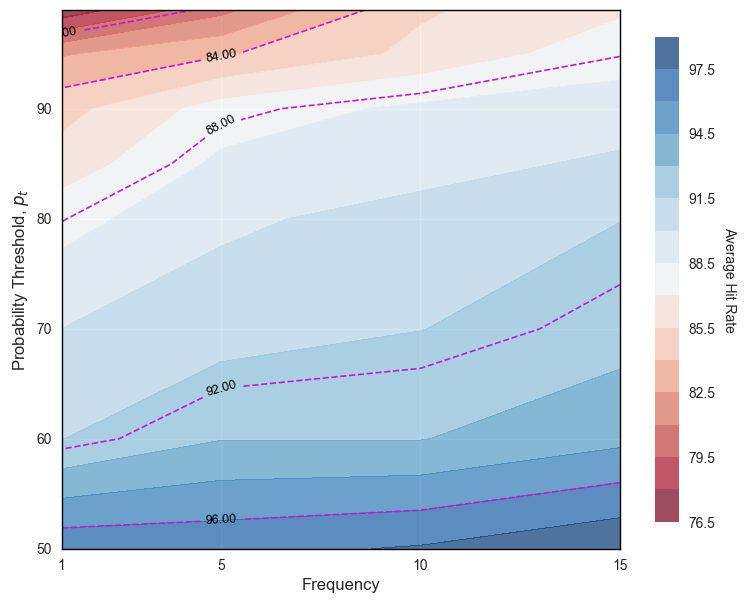

In [164]:
# Colormap
csv_file_1 = "./outputs/forecast_evaluation_metrics_1_R_0.25.csv"
csv_file_2 = "./outputs/forecast_evaluation_metrics_5_R_0.25.csv"
csv_file_3 = "./outputs/forecast_evaluation_metrics_10_R_0.25.csv"
csv_file_4 = "./outputs/forecast_evaluation_metrics_15_R_0.25.csv"

df1 = pd.read_csv(csv_file_1)
df2 = pd.read_csv(csv_file_2)
df3 = pd.read_csv(csv_file_3)
df4 = pd.read_csv(csv_file_4)

# Combine them vertically into a single dataframe
combined_df = pd.concat([df1, df2, df3, df4], ignore_index=True)

metric_eval = 'hit_rate' # Choose "hit_rate" or "false_alarm_rate"
grouped_df = combined_df.groupby(['p_t', 'frequency'])[metric_eval].mean().reset_index()
pivot_df = grouped_df.pivot(index='p_t', columns='frequency', values=metric_eval)

X = pivot_df.columns.astype(float).values
Y = pivot_df.index.astype(float).values
Z = pivot_df.values

# --- 3. Generate the Contour Heatmap Plot ---
fig, ax = plt.subplots(figsize=(9, 7))

# Plot filled contours (the color gradient background)
heatmap = ax.contourf(X, Y, Z, levels=20, cmap='RdBu', alpha=0.7)
cbar = fig.colorbar(heatmap, ax=ax, shrink=0.9, aspect=20,)
cbar.set_label('Average Hit Rate', rotation=270, labelpad=15, fontsize=10)
cbar.ax.tick_params(labelsize=10)

# Overlay the crisp black contour lines on top
contour_lines = ax.contour(X, Y, Z, levels=5, colors="#c319d2", linewidths=1.2, linestyles='dashed')
ax.clabel(contour_lines, inline=True, fmt='%.2f', fontsize=9, colors='k')

ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Probability Threshold, $p_t$', fontsize=12)
ax.set_xticks(X)
ax.tick_params(axis='both', which='major', labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')

# plt.savefig(f"{metric_eval} heatmap stochastic update; eval_criteria if ever crossed", dpi=300, bbox_inches='tight')

In [ ]:
# Plot Hit Rate and FAR vs. Frequency
fontsize=19
linewidth=3
plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5,5))
frequencies = np.array([1, 5, 10, 20, 30])
hit_rate = np.array([86.765, 97.06, 98.529, 98.529, 100])
far = np.array([6.837, 6.268, 4.8433, 2.849, 2.279])

ax1.plot(frequencies, hit_rate, color="#12c855", linewidth=linewidth)
ax2 = ax1.twinx()
ax2.plot(frequencies, far, color="#cd154d", linewidth=linewidth)


# Plotting Style
ax1.set_xlabel(f"Frequency (Samples/Hour)", fontsize=fontsize)
ax1.set_ylabel(f"Hit Rate", fontsize=fontsize, color="#12c855")
ax2.set_ylabel(f"False Alarm Rate", fontsize=fontsize, color="#cd154d")
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
ax2.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
ax1.set_title(f"Q: {Q}, R: {R}, $\\sigma$: {sigma}, $p_t$: 0.80")
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')
ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')
ax2.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')

# plt.savefig(f'./Full EnKF Frequency {frequency} without orchestrator', dpi=150, bbox_inches='tight')

# R is the variance, while Q is the standard deviation
# Sensor measurements are +- 7ft from the ground truth on average
# The variance of the forecast at current time is also 49ft^2 or +-7ft.

In [ ]:
fontsize=19
linewidth=3
plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5,5))

data_sigma_min = np.array([95.588,95.588,95.588,95.588,95.588,95.588,95.588]) #sigma=0.1
data_sigma_low = np.array([77.94, 80.882, 82.359, 86.765, 86.765, 86.765, 86.765]) #sigma=2
data_sigma_high = np.array([48.53, 54.411, 58.823, 63.235, 69.1174, 75, 76.47]) # sigma=5
freq=np.array([1,5,10,20,30,40,50])
ax1.plot(freq, data_sigma_min, label=r"$\sigma=Q=0.1$, $R=0.05$", linewidth=linewidth)
ax1.plot(freq, data_sigma_low, label=r"$\sigma=Q=2$, $R=1$", linewidth=linewidth)
ax1.plot(freq, data_sigma_high, label=r"$\sigma=Q=5$, $R=2.5$", linewidth=linewidth)
ax1.set_title(r'Hit Rate: $p_t=0.95$, $Horizon=12$')
ax1.legend()
ax1.set_xlabel(f"Frequency", fontsize=fontsize)
ax1.set_ylabel(r"Hit Rate $H_{p_t}$", fontsize=fontsize)
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
ax1.legend(ncols=1, fancybox=True, shadow=True,
           frameon=True, facecolor='lightgrey', prop={'size':10})
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')
# plt.savefig('./Hit rate vs Frequency', dpi=150, bbox_inches='tight')

Plot one output from the Fixed Horizon EnKF

In [ ]:
fontsize=19
linewidth=3
plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5,5))
# y_times = obs_df_dedup.reset_index()["Unit"]
# y = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]

y_times = obs_df_synthetic.reset_index()["Unit"]
y = obs_df_synthetic.reset_index()["Instantaneous Stream Level (ft)"]

window = 0
index = 10
results = pd.DataFrame(analysis_results)
results = results.loc[results["window_id"]==window]


# t0 = results['timestamps'].iloc[0][0]
# t1 = results['timestamps'].iloc[0][-1]

t0 = results['timestamps'].iloc[0].iloc[0]
t1 = results['timestamps'].iloc[0].iloc[-1]

mask_1 = (y_times >= t0) & (y_times <= t1)
ax1.plot(y_times[mask_1], y[mask_1], alpha=0.5, color="tab:red", linewidth=linewidth, label="Measurements")
ax1.scatter(y_times[mask_1].iloc[index], y[mask_1].iloc[index], marker='*', color='gold', s=200, 
         edgecolors='black', label="Current Measurement", zorder=5)

mean_signal = []
lower_ci = []
upper_ci = []
# ax1.set_ylim(7.5, 14)
# mean_signal.append(results["mean"].iloc[index])
lower_ci.append(results["lower_ci"].iloc[index])
upper_ci.append(results["upper_ci"].iloc[index])

# ax1.plot(y_times[mask_1], mean_signal[0], color='crimson', linewidth=linewidth)
ax1.fill_between(y_times[mask_1], lower_ci[0], upper_ci[0], color="#9d4edd", alpha=0.5, label=f'Estimated State, X({index+1}|{index+1})')
ax1.fill_between(y_times[mask_1], np.percentile(results["X_f"].iloc[index], 97.5, axis=1), np.percentile(results["X_f"].iloc[index], 2.5, axis=1),
                 alpha=0.5, color="#00296b", label=f"Predicted State, X({index+1}|{index})")

# Plotting Style
ax1.set_xlabel(f"Time", fontsize=fontsize)
ax1.set_ylabel(f"Stream Level", fontsize=fontsize)
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
ax1.set_title(f"Frequency: {frequency}, Q: {Q}, R: {R}, $\\sigma$: {sigma}")
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles=handles, labels=labels, loc='upper center', bbox_to_anchor=(0.48, -0.24), ncols=5,
            fancybox=True, shadow=True, frameon=True, facecolor='lightgrey', prop={'size':12.5}, handletextpad=0.35, columnspacing=0.75)
# plt.savefig(f'./Full EnKF Frequency {frequency} without orchestrator', dpi=150, bbox_inches='tight')

In [ ]:
# Plot from the stored parquet files
# --- 1. Load and Process the EnKF Parquet Data ---
# Replace with your actual path and target window index
output_path = f"./Saved Parquets Frequency 15 Sigma 2 R 4 Resampled Trial 9 Debug With PN Using growth_martingale Stochastic update/output.parquet" 
target_window = 151
target_obs_step = 10
seg_path = output_path.replace(".parquet", f"_seg{target_window:05d}.parquet")


if not os.path.exists(seg_path):
    raise FileNotFoundError(f"Could not find the parquet file at {seg_path}")

df = pd.read_parquet(seg_path)

# Choose which observation step snapshot you want to visualize. 
# To see the final assimilated state of this window, select the last obs_step.
df_assimilated = df[df['obs_step'] == target_obs_step]

# Plot ground truth
y_times_ground_truth = obs_df_dedup.reset_index()["Unit"]
y_ground_truth = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]
t0 = df["timestamp"].min()
t1 = df["timestamp"].max()
mask_1 = (y_times_ground_truth >= t0) & (y_times_ground_truth <= t1)

# Compute the mean and 95% Confidence Interval (2.5% to 97.5%) across the ensembles
ci_summary = (df_assimilated.groupby('timestamp')['value'].agg(mean='mean', lower_ci=lambda x: np.percentile(x, 2.5), upper_ci=lambda x: np.percentile(x, 97.5))
            .reset_index()
            .sort_values('timestamp')
        )

fontsize = 19
linewidth = 3

plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5, 5))

y_times = obs_df_synthetic.reset_index()["Unit"]
y = obs_df_synthetic.reset_index()["Instantaneous Stream Level (ft)"]
t0, t1 = ci_summary['timestamp'].iloc[0], ci_summary['timestamp'].iloc[-1]
mask_1 = (y_times >= t0) & (y_times <= t1)
ax1.plot(y_times[mask_1], y[mask_1], alpha=0.5, color="tab:red", linewidth=linewidth, label="Measurements")
ax1.plot(y_times_ground_truth[mask_1], y_ground_truth[mask_1], alpha=0.5, color="tab:orange", linewidth=linewidth, label="Ground Truth")

# Plot the 95% Confidence Interval for the Assimilated/Estimated State
ax1.fill_between(
    ci_summary['timestamp'], 
    ci_summary['lower_ci'], 
    ci_summary['upper_ci'], 
    color="#9d4edd", 
    alpha=0.5, 
    label=f'Estimated State CI (95%)'
)
ax1.plot(
    ci_summary['timestamp'], 
    ci_summary['mean'], 
    color='#5a189a', 
    linewidth=linewidth - 1, 
    label='Ensemble Mean'
)

# Plotting Style & Aesthetics
ax1.set_xlabel("Time", fontsize=fontsize)
ax1.set_ylabel("Stream Level", fontsize=fontsize)
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)

# Metadata for the title (replace with actual variables if available)
ax1.set_title(f"Assimilated Forecast (Window {target_window}, Obs Step {target_obs_step})")

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')

# Legend styling matching your template
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles=handles, labels=labels, loc='upper center', bbox_to_anchor=(0.48, -0.24), ncols=5,
    fancybox=True, shadow=True, frameon=True, facecolor='lightgrey', prop={'size': 12.5}, 
    handletextpad=0.35, columnspacing=0.75
)
# plt.savefig(f'./Full EnKF, Frequency 25 Obs {target_obs_step} R 14', dpi=150, bbox_inches='tight')
plt.show()

Generating Frames of EnKF assimilation

In [ ]:
fontsize = 19
linewidth = 3
# matplotlib.use("agg")
plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5, 5))
fig.subplots_adjust(bottom=0.3)
y_times_ground_truth = obs_df_dedup.reset_index()["Unit"]
y_ground_truth = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]

y_times = obs_df_synthetic.reset_index()["Unit"]
y = obs_df_synthetic.reset_index()["Instantaneous Stream Level (ft)"]

window = 1
results = pd.DataFrame(analysis_results)
results = results.loc[results["window_id"] == window]

t0 = results['timestamps'].iloc[0].iloc[0]
t1 = results['timestamps'].iloc[0].iloc[-1]

mask_1 = (y_times >= t0) & (y_times <= t1)

ax1.plot(y_times[mask_1], y[mask_1], alpha=0.5, color="tab:red", linewidth=linewidth, label="Measurements")
ax1.plot(y_times_ground_truth[mask_1], y_ground_truth[mask_1], alpha=0.5, color="tab:orange", linewidth=linewidth, label="Ground Truth")

ax1.set_xlabel("Time", fontsize=fontsize)
ax1.set_ylabel("Stream Level", fontsize=fontsize)
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
# ax1.set_ylim(-10, 30)
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')

star = ax1.scatter([], [], marker='*', s=200, edgecolors='black', zorder=5, color='gold', label='Current Measurement')
mean_line, = ax1.plot([], [], color="#229b12", linewidth=2.5, linestyle="-", zorder=4, label="Estimated Mean")
analysis_fill = None
forecast_fill = None

def update(index):
    global analysis_fill, forecast_fill

    if analysis_fill is not None:
        analysis_fill.remove()
    if forecast_fill is not None:
        forecast_fill.remove()

    # Update measurement star
    star.set_offsets([[y_times[mask_1].iloc[index],y[mask_1].iloc[index]]])
    mean_line.set_data(y_times[mask_1], results["mean"].iloc[index])

    # Analysis CI
    analysis_fill = ax1.fill_between(y_times[mask_1], results["lower_ci"].iloc[index], results["upper_ci"].iloc[index],
        color="#9d4edd",alpha=0.5,label=f'Estimated State, X({index+1}|{index+1})')
    
    # Forecast CI
    forecast_fill = ax1.fill_between(y_times[mask_1], np.percentile(results["X_f"].iloc[index], 97.5, axis=1), np.percentile(results["X_f"].iloc[index], 2.5, axis=1),
        alpha=0.5,color="#00296b",label=f"Predicted State")
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles, labels, loc='lower center', ncol=6,frameon=True, fancybox=True, facecolor='lightgrey', shadow=True, prop={'size':11})
    return star,

n_frames = len(results)
ani = FuncAnimation(fig, update, frames=n_frames, interval=1000, repeat=True, blit=False)
fig.tight_layout()
# ani.save(f"./enkf_assimilation_window_{window}_frequency_{frequency}_R_{R}_new.mp4", dpi=150, fps=0.5)

In [96]:
# Generating Frames from Parquet Files
frequency_v = 5
base_path=f"./outputs/Saved Parquets Frequency {frequency_v} Sigma 3 R 0.25 Trial 0/"
output_path = base_path + "output.parquet"
target_window = 4
seg_path = output_path.replace(".parquet", f"_seg{target_window:05d}.parquet")

if not os.path.exists(seg_path):
    raise FileNotFoundError(f"Could not find the parquet file at {seg_path}")

df = pd.read_parquet(seg_path)
all_obs_steps = sorted(df['obs_step'].unique())

# --- CONFIGURATION: How many ensemble members to plot? ---
NUM_MEMBERS_TO_PLOT = 0
member_col = 'ensemble_id'
available_members = sorted(df[member_col].unique())[:NUM_MEMBERS_TO_PLOT]

# --- 2. Setup Static Plot Elements (Ground Truth & Measurements) ---
fontsize = 19
linewidth = 3
plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5, 5))
fig.subplots_adjust(bottom=0.3)

# Plot ground truth & measurements (these don't change per frame)
obs_df_dedup = pd.read_parquet(base_path + "obs_df_dedup.parquet")
y_times_ground_truth = obs_df_dedup.reset_index()["Unit"]
y_ground_truth = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]
obs_df_synthetic = pd.read_parquet(base_path + "obs_df_synthetic.parquet")
y_times = obs_df_synthetic.reset_index()["Unit"]
y = obs_df_synthetic.reset_index()["Instantaneous Stream Level (ft)"]

t0 = df["timestamp"].min()
t1 = df["timestamp"].max()
mask_1 = (y_times >= t0) & (y_times <= t1)

# Measurements and Ground Truth
ax1.plot(y_times[mask_1], y[mask_1], alpha=0.5, color="tab:red", linewidth=linewidth, label="Measurements")
ax1.plot(y_times_ground_truth[mask_1], y_ground_truth[mask_1], alpha=0.5, color="tab:orange", linewidth=linewidth, label="Ground Truth")


poly_collection = None
mean_line, = ax1.plot([], [], color='#229b12', linewidth=linewidth - 1,linestyle="-", label='Ensemble Mean')
star = ax1.scatter([], [], marker='*', s=200, edgecolors='black', zorder=5, color='gold', label='Current Measurement')
member_lines = []

# Styling & Aesthetics (Static)
ax1.set_xlabel("Time", fontsize=fontsize)
ax1.set_ylabel("Stream Level", fontsize=fontsize)
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')

# Optional: ax1.set_ylim(ymin, ymax) -> Recommended if the y-axis bounces drastically
# ax1.set_ylim(10, 60)

# --- 3. Animation Update Function ---
def update(frame_idx):
    global poly_collection
    
    current_obs_step = all_obs_steps[frame_idx]
    df_assimilated = df[df['obs_step'] == current_obs_step]
    
    # Compute CI summary for the current step
    ci_summary = (df_assimilated.groupby('timestamp')['value']
                  .agg(mean='mean', 
                       lower_ci=lambda x: np.percentile(x, 2.5), 
                       upper_ci=lambda x: np.percentile(x, 97.5))
                  .reset_index()
                  .sort_values('timestamp'))
    
    # 1. Remove the previous frame's fill_between collection if it exists
    if poly_collection is not None:
        poly_collection.remove()

    for line in member_lines:
        line.remove()
    member_lines.clear()
        
    # 2. Draw the new 95% Confidence Interval
    poly_collection = ax1.fill_between(
        ci_summary['timestamp'], 
        ci_summary['lower_ci'], 
        ci_summary['upper_ci'], 
        color="#00296b", 
        alpha=0.5,
        label = f"Estimated State, X({frame_idx+1}|{frame_idx+1})",
    )
    
    # 3. Update the mean line data
    mean_line.set_data(ci_summary['timestamp'], ci_summary['mean'])
    star.set_offsets([[y_times[mask_1].iloc[frame_idx], y[mask_1].iloc[frame_idx]]])

    for i, m_id in enumerate(available_members):
        member_data = df_assimilated[df_assimilated[member_col] == m_id].sort_values('timestamp')
        lbl = "Ensemble Members" if i == 0 else ""
        
        l, = ax1.plot(member_data['timestamp'], member_data['value'], color="#e0e711", linewidth=2.0, alpha=0.75, linestyle=':', label=lbl)
        member_lines.append(l)

    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles, labels, loc='lower center', ncol=6,frameon=True, fancybox=True, facecolor='lightgrey', shadow=True, prop={'size':11})

    # Return the modified artists for blitting optimization
    return poly_collection, mean_line

# --- 4. Render and Save the Animation ---
ani = FuncAnimation(fig, update, frames=len(all_obs_steps), interval=1000, blit=False)
fig.tight_layout()
video_filename = f"./outputs/EnKF_Window_{target_window}_Assimilation F{frequency_v}.mp4"
ani.save(video_filename, writer='ffmpeg', dpi=150)
plt.close()

<Figure size 1400x500 with 0 Axes>

Curve Fitting for Hit Rate and False Alarm Rate

ANALYTICAL FUNCTION DERIVED FOR p_t = 80
H(f) = 92.1650 - 4.7277 * e^(-0.1209 * f)
R-squared Accuracy Score: 0.9927


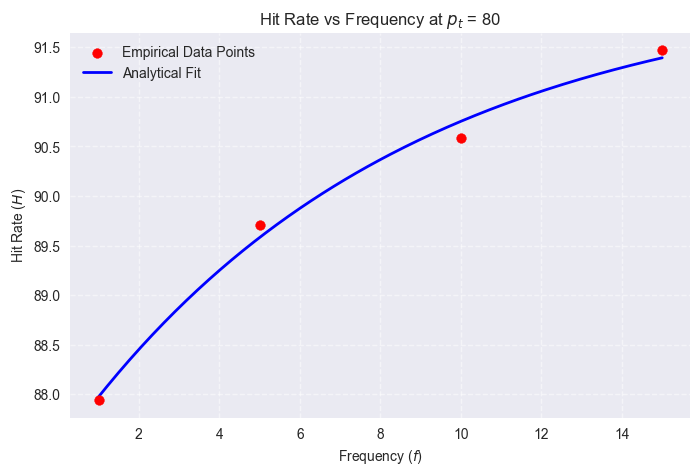

In [186]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

def asymptotic_exponential(f, A, B, k):
    """ Model: H(f) = A - B * exp(-k * f) """
    return A - B * np.exp(-k * f)

csv_files = [
    "./outputs/forecast_evaluation_metrics_1_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_5_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_10_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_15_R_0.25.csv"
]
combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
CHOSEN_PT = 80 

slice_df = combined_df[combined_df['p_t'] == CHOSEN_PT]
grouped_slice = slice_df.groupby('frequency')['hit_rate'].mean().reset_index()
frequencies = grouped_slice['frequency'].astype(float).values
hit_rates = grouped_slice['hit_rate'].astype(float).values

# --- Fit the Analytical Function ---
# P0 provides initial guesses to help the optimizer converge safely:
# Guessing max hit rate (A) = 100, drop scale (B) = 50, growth rate (k) = 0.1
initial_guesses = [100, 50, 0.1]

popt, pcov = curve_fit(asymptotic_exponential, frequencies, hit_rates, p0=initial_guesses, maxfev=5000)
A_fit, B_fit, k_fit = popt

# Evaluate Fit Quality
predictions = asymptotic_exponential(frequencies, A_fit, B_fit, k_fit)
r2 = r2_score(hit_rates, predictions)

print("=" * 50)
print(f"ANALYTICAL FUNCTION DERIVED FOR p_t = {CHOSEN_PT}")
print("=" * 50)
print(f"H(f) = {A_fit:.4f} - {B_fit:.4f} * e^(-{k_fit:.4f} * f)")
print(f"R-squared Accuracy Score: {r2:.4f}")
print("=" * 50)

plt.figure(figsize=(8, 5))
plt.scatter(frequencies, hit_rates, color='red', zorder=3, label='Empirical Data Points')

f_smooth = np.linspace(frequencies.min(), frequencies.max(), 200)
h_smooth = asymptotic_exponential(f_smooth, A_fit, B_fit, k_fit)
plt.plot(f_smooth, h_smooth, color='blue', linewidth=2, label=f'Analytical Fit')

plt.title(f'Hit Rate vs Frequency at $p_t$ = {CHOSEN_PT}', fontsize=12)
plt.xlabel('Frequency ($f$)', fontsize=10)
plt.ylabel('Hit Rate ($H$)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

ANALYTICAL FUNCTION DERIVED FOR FALSE ALARM RATE (p_t = 80)
FAR(f) = 0.2329 * e^(-0.3036 * f) + 0.0000
R-squared Accuracy Score: 0.9914


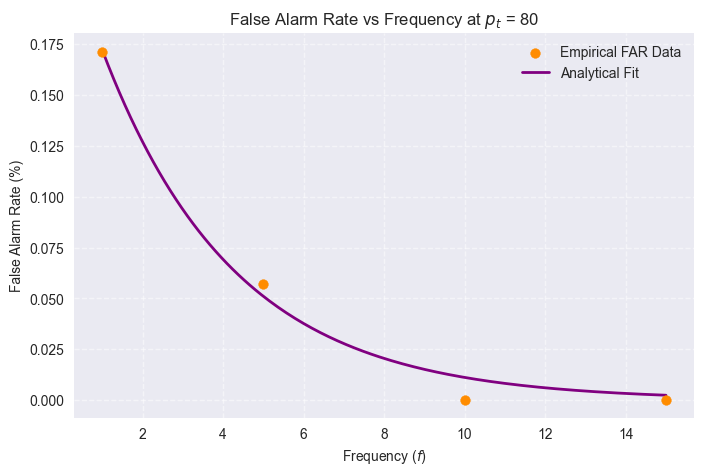

In [185]:
def exponential_decay(f, A, k, C):
    """ Model: FAR(f) = A * exp(-k * f) + C """
    return A * np.exp(-k * f) + C

csv_files = [
    "./outputs/forecast_evaluation_metrics_1_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_5_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_10_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_15_R_0.25.csv"
]
combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
CHOSEN_PT = 80

slice_df = combined_df[combined_df['p_t'] == CHOSEN_PT]
grouped_slice = slice_df.groupby('frequency')['false_alarm_rate'].mean().reset_index()
frequencies = grouped_slice['frequency'].astype(float).values
far_values = grouped_slice['false_alarm_rate'].astype(float).values

# --- Fit the Analytical Function ---
# Guessing max baseline FAR (A) = max observed value, decay rate (k) = 0.1, floor (C) = 0
initial_guesses = [max(far_values), 0.1, 0.0]

# We set bounds to prevent the optimizer from drifting into unphysical space
# A must be positive, k must be positive (to decay), C must be positive or zero
param_bounds = ((0, 0, 0), (np.inf, np.inf, np.inf))

popt, pcov = curve_fit(exponential_decay, frequencies, far_values, p0=initial_guesses, bounds=param_bounds, maxfev=5000)
A_fit, k_fit, C_fit = popt

# Evaluate Fit Quality
predictions = exponential_decay(frequencies, A_fit, k_fit, C_fit)
r2 = r2_score(far_values, predictions)

# --- 4. Print the Final Explicit Formula ---
print("=" * 50)
print(f"ANALYTICAL FUNCTION DERIVED FOR FALSE ALARM RATE (p_t = {CHOSEN_PT})")
print("=" * 50)
print(f"FAR(f) = {A_fit:.4f} * e^(-{k_fit:.4f} * f) + {C_fit:.4f}")
print(f"R-squared Accuracy Score: {r2:.4f}")
print("=" * 50)

# --- 5. Visual Validation ---
plt.figure(figsize=(8, 5))
plt.scatter(frequencies, far_values, color='darkorange', zorder=3, label='Empirical FAR Data')

# Generate smooth line for the analytical function
f_smooth = np.linspace(frequencies.min(), frequencies.max(), 200)
far_smooth = exponential_decay(f_smooth, A_fit, k_fit, C_fit)
plt.plot(f_smooth, far_smooth, color='purple', linewidth=2, label=f'Analytical Fit')

plt.title(f'False Alarm Rate vs Frequency at $p_t$ = {CHOSEN_PT}', fontsize=12)
plt.xlabel('Frequency ($f$)', fontsize=10)
plt.ylabel('False Alarm Rate (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

MPC Controller Optimizing the Value of Forecasts

In [50]:
def mpc_objective(params, current_window, effective_horizon, initial_soc, weight_voi, weight_energy, harvest_belief):
    """
    Objective function for MPC step.
    params: Decision variables (f_s and f_t) for the effective_horizon windows.
    current_window: Starting window index for the MPC step.
    effective_horizon: Number of windows to optimize (prediction horizon).
    initial_soc: Initial State of Charge at current_window.
    """
    SoC = initial_soc
    total_utility = 0
    
    f_s = params[:effective_horizon]  # Effective horizon is the number of windows forward that we are looking into.
    # f_t = params[effective_horizon:]
    
    for k in range(effective_horizon):
        # absolute_window = current_window + k  # Absolute Window is the window for which the optimizer is currently optimizing for
        discount_factor = 1 / (discount_denom ** k)  # Discounting is applied to the effective horizon of the MPC
        soe, cond = energy_ratio(SoC, f_s[k], f_s[k], window=k, peak_power=harvest_belief)
        if SoC > 0:
            if soe > 0:
                value = value_of_eps(clr, baro, f_s[k])
                norm_value = normalize_veps(value, clr, baro)
                energy = soe
                utility = (weight_voi * norm_value + weight_energy * (energy / 100)) * discount_factor
                total_utility += utility
        SoC = cond
        # _, SoC = energy_ratio(SoC, f_s[k], f_t[k], window=k, peak_power=harvest_belief, date_base=date_base)
    return -1e5*total_utility

In [ ]:
# SLSQP Solver (One Shot MPC)
current_window=0
effective_horizon=12
SoC = 33.29
harvest_belief = update_harvest_belief(current_window, effective_horizon)
x0 = 1 * np.ones(effective_horizon)

constr_energy_args = (effective_horizon, SoC, harvest_belief)
cons_energy = {'type': 'ineq', 'fun': energy_constraint, 'args': constr_energy_args}

nm = minimize(mpc_objective,
        x0 = x0,
        args=(current_window, effective_horizon, SoC,
              0.5, 0.5, 
              harvest_belief),
        bounds=[(lowerbound_fs, upperbound_fs)]*effective_horizon,
        constraints=[cons_energy],
        method='SLSQP',
        jac='2-point',
        options={'maxiter':1e3, 'ftol': 1e-5}
      )

SystemError: <built-in function slsqp> returned a result with an exception set

Plot Graphs of VoI and SoE of two errors

In [ ]:
fontsize=19
linewidth=3
plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5,5))
start_date = datetime.datetime(2021, 7, 19, 0, 0, 0)
num_windows = len(system_states_unaware_bf_errorsmall['freq_sensing'])
date_list = [start_date + datetime.timedelta(hours=t) for t in range(num_windows)]

first_elements_sense_low = [np.atleast_1d(arr)[0] for arr in system_states_unaware_bf_errorsmall['freq_sensing']]
zipped_values_sense_low = list(zip(first_elements_sense_low))
first_elements_sense_high = [np.atleast_1d(arr)[0] for arr in system_states_unaware_bf['freq_sensing']]
zipped_values_sense_high = list(zip(first_elements_sense_high))
ax1.plot(date_list, zipped_values_sense_low, label=r'Frequency Small $\sigma$', color='darkslateblue', lw=linewidth)
ax1.plot(date_list, zipped_values_sense_high, label=r'Frequency Large $\sigma$', color='darkslateblue', linestyle='dashed', lw=linewidth)

# Plot stream Level
ax2 = ax1.twinx()
wdepth=np.array([item[0] for item in system_states_unaware_bf_errorsmall["threat_belief"] if len(item)>0])
ax2.plot(date_list, wdepth, lw=linewidth, color='red', alpha=0.75, label='Water Depth')
ax2.set_ylabel('Water Elevation, (ft)', color='red', fontsize=fontsize)
ax2.axhline(3, linestyle=(0, (3, 5, 1, 5, 1, 5)), lw=2, color='red', alpha=0.75, zorder=100) # Plot horizontal Dashed Line
ax2.fill_between(date_list, wdepth, 3, where=(wdepth >= 3), alpha=0.3)

# Plot SoE
date_list_soe = [start_date + datetime.timedelta(hours=t) for t in range(num_windows)]
soe_color = '#5fa052'
ax3 = ax2.twinx()
ax2.yaxis.tick_right()
ax3.spines['right'].set_position(("axes", 1.09))
# ax3.plot(date_list_soe, soe)
ax3.plot(date_list_soe, soe_errorsmall, linestyle='solid', color=soe_color, lw=linewidth, label=r'SoE Small $\sigma$', zorder=100)
ax3.plot(date_list_soe, soe, linestyle='dashed', color=soe_color, lw=linewidth, label=r'SoE Large $\sigma$', zorder=100)
ax3.set_ylabel('State of Energy (%)', color=soe_color, fontsize=fontsize)

ax1.ticklabel_format(axis='y', style='plain')
ax1.set_xlabel("Day", fontsize=fontsize)
ax1.set_ylabel("Frequency (Samples/Hour)", fontsize=fontsize)
plt.grid(True, linestyle='--', alpha=0.95, color='#b0c4de')
ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')
ax2.grid(True, linestyle='--', alpha=0.95, color='#b0c4de')

# Format the x-axis to show date and time
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)

# Spines
for ax in [ax1, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')
# Ticks
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
ax2.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
ax3.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)

#Legend
legend_handles = ax1.get_legend_handles_labels()
legend_handles_2 = ax2.get_legend_handles_labels()
legend_handles_3 = ax3.get_legend_handles_labels()
ax1.legend(handles=legend_handles[0] + legend_handles_2[0] + legend_handles_3[0],
           labels=legend_handles[1] + legend_handles_2[1] + legend_handles_3[1],
           loc='upper center',
           bbox_to_anchor=(0.53, -0.17),
           ncols=5, fancybox=True, shadow=True,
           frameon=True, facecolor='lightgrey', prop={'size':15},
           handletextpad=0.35,
           columnspacing=0.75)
# plt.savefig('./Performance Comparison Small and Larger Error, Uncertainty Unaware SMPC, 500mAh buffer size', dpi=150, bbox_inches='tight')

In [ ]:
fontsize=19
linewidth=3
first_elements_sense = [np.atleast_1d(arr)[0] for arr in system_states_unaware_bf['freq_sensing']]
zipped_values_sense = list(zip(first_elements_sense))

first_elements_transmit = [np.atleast_1d(arr)[0] for arr in system_states_unaware_bf['freq_transmission']]
zipped_values_transmit = list(zip(first_elements_transmit))
num_windows = len(system_states_unaware_bf['freq_sensing'])

# Define the starting date and time
start_date = datetime.datetime(2021, 7, 19, 0, 0, 0)

# Create a list of datetime objects for each window
date_list = [start_date + datetime.timedelta(hours=t) for t in range(num_windows)]

plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5,5))

# Plot stream Level
ax2 = ax1.twinx()
wdepth=np.array([item[0] for item in system_states_unaware_bf["threat_belief"] if len(item)>0])
ax2.plot(date_list[3:], wdepth[3:], lw=linewidth, color='red', alpha=0.75, label='Water Depth')
ax2.set_ylabel('Water Elevation, (ft)', color='red', fontsize=fontsize)
ax2.axhline(3, linestyle=(0, (3, 5, 1, 5, 1, 5)), lw=2, color='red', alpha=0.75, zorder=100) # Plot horizontal Dashed Line
# ax2.fill_between(date_list[3:], np.array(system_states['threat_belief'][3:]) + 0.3, np.array(system_states['threat_belief'][3:]) - 0.3)
ax2.fill_between(date_list[3:], wdepth[3:], 3, where=(wdepth[3:] >= 3), alpha=0.3)

# Plot SoE
date_list_soe = [start_date + datetime.timedelta(hours=t) for t in range(num_windows)]
soe_color = '#5fa052'
ax3 = ax2.twinx()
ax2.yaxis.tick_right()
ax3.spines['right'].set_position(("axes", 1.09))
ax3.plot(date_list_soe[3:], soe[3:], linestyle='solid', color=soe_color, lw=linewidth, label='State of Energy', zorder=100)
ax3.set_ylabel('State of Energy (%)', color=soe_color, fontsize=fontsize)

# Plot Frequencies
ax1.plot(date_list[3:], zipped_values_sense[3:], lw=linewidth,linestyle='solid', color='darkslateblue', label='Sensing Frequency', zorder=100)
ax1.plot(date_list[3:], zipped_values_transmit[3:], lw=linewidth,linestyle='solid', color='magenta', alpha = 0.75, label='Transmission Frequency', zorder=100)

ax1.ticklabel_format(axis='y', style='plain')
ax1.set_xlabel("Day", fontsize=fontsize)
ax1.set_ylabel("Frequency (Samples/Hour)", fontsize=fontsize)
plt.grid(True, linestyle='--', alpha=0.95, color='#b0c4de')
ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')
ax2.grid(True, linestyle='--', alpha=0.95, color='#b0c4de')

# Format the x-axis to show date and time
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)

# Spines
for ax in [ax1, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')
# Ticks
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
ax2.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
ax3.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)

# # Plot Sunlight Bars
# max_sun = max(solar_df["Average"])
# min_sun = 0
# print(max_sun, min_sun)
# for date in date_list[3:]:
#     shifted_date = date.replace(year=2021)
#     match = solar_df.loc[solar_df["datetime"] == shifted_date]
#     sun_intensity = match["Average"]
#     sun_norm = 0 + (((sun_intensity - min_sun)*(120 - 0)) / (max_sun - min_sun))
#     ax1.bar(date, sun_norm, width=0.04, color="xkcd:dull orange", zorder=0, alpha=0.75, edgecolor="yellow")

# Legend
from matplotlib.patches import Patch
legend_handles = ax1.get_legend_handles_labels()
legend_handles_2 = ax2.get_legend_handles_labels()
legend_handles_3 = ax3.get_legend_handles_labels()
# sunlight_patch = Patch(color='xkcd:dull orange', alpha=0.75, label='Sunlight Intensity')
ax1.legend(handles=legend_handles[0] + legend_handles_2[0] + legend_handles_3[0], #sunlight_patch
           labels=legend_handles[1] + legend_handles_2[1] + legend_handles_3[1], #['Sunlight Intensity']
           loc='upper center',
           bbox_to_anchor=(0.53, -0.17),
           ncols=5, fancybox=True, shadow=True,
           frameon=True, facecolor='lightgrey', prop={'size':15},
           handletextpad=0.35,
           columnspacing=0.75)
plt.tight_layout()
# plt.savefig('./hindcasting-monday-8-epsilon1-availability01-250mah-0035panel-riskinclined-moreRI-full', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
system_states_reduced_observer = {
    'SoC_actual' : [],
    'SoC_noisy':[],
    'harvest_belief' : [],
    'freq_sensing' : [],
    'freq_transmission' : [],
    'threat_belief': [],
    'utility_noisy' : [],
    'utility_actual': [],
    'voi_actual': [],
    'voi_noisy':[],
    'optim_msg': [],
    'time':[]
}

In [ ]:
# ground_truth = pd.read_csv(r"C:\LUMS\Full Deployment\telemetry_monday_8.csv", parse_dates = ["Time Payload Received"], usecols=["Time Payload Received", "Water Depth"])
# ground_truth = ground_truth.iloc[956:]
# ground_truth = pd.read_csv(r"C:\LUMS\USB Backup\LUMS\Namal Dataset\threat_data_raw.csv", parse_dates = ["Unit"], usecols=["Unit", "Instantaneous Stream Level (ft)"])
ground_truth=threat_data_raw

In [ ]:
first_elements_sense = [np.atleast_1d(arr)[0] for arr in system_states_reduced_observer['freq_sensing']]
zipped_values_sense = list(zip(first_elements_sense))

first_elements_transmit = [np.atleast_1d(arr)[0] for arr in system_states_reduced_observer['freq_transmission']]
zipped_values_transmit = list(zip(first_elements_transmit))
num_windows = len(system_states_reduced_observer['freq_sensing'])

In [ ]:
inter_transmission_time = [60/x for x in first_elements_transmit]
inter_sample_time = [60/x for x in first_elements_sense]

In [ ]:
timestamps = []
current_time = ground_truth['Unit'].iloc[0]
end_time = ground_truth['Unit'].iloc[431]

interval_index = 0
interval_minutes = inter_transmission_time[interval_index]
next_update_threshold = current_time + datetime.timedelta(hours=1)

while current_time <= end_time:
    timestamps.append(current_time)
    next_target = current_time + datetime.timedelta(minutes=interval_minutes)
    if next_target > end_time:
        break
    current_time = next_target
    # update sampling interval every hour
    if current_time >= next_update_threshold:
        interval_index += 1
        if interval_index < len(inter_transmission_time):
            interval_minutes = inter_transmission_time[interval_index]
            next_update_threshold += datetime.timedelta(hours=1)
        else:
            break
target_idx = pd.DatetimeIndex(timestamps)
df = ground_truth.set_index('Unit')[['Instantaneous Stream Level (ft)']]
df = df.reindex(df.index.union(target_idx)).sort_index()
df_interpolated = df.interpolate(method='time')
downsampled_df_1 = df_interpolated.loc[target_idx].reset_index()
downsampled_df_1.columns = ['Time Payload Received', 'Water Depth']